In [127]:
# Copyright (C) 2026 ETH Zurich, Shu-Yu Chen
import sys
import os
import seaborn as sns
# Save original path
original_sys_path = sys.path.copy()

# Remove custom entries not in original sys.path (like PYTHONPATH entries) to avoid numpy conflict
sys.path = [p for p in sys.path if "amber" not in p]
for i, path in enumerate(sys.path):
    print(f"{i}: {path}")

0: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python36.zip
1: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6
2: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/lib-dynload
3: 
4: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages
5: /localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages/IPython/extensions
6: /home/shuchen/.ipython


In [128]:
import numpy, pandas, matplotlib, pytraj, seaborn

In [129]:
# paste package versions
print(f"Python version: {sys.version}")
packages = [numpy, pandas, matplotlib, pytraj, seaborn]
for pkg in packages:
    print(f"{pkg.__name__} version: {pkg.__version__}")


Python version: 3.6.15 | packaged by conda-forge | (default, Dec  3 2021, 18:49:41) 
[GCC 9.4.0]
numpy version: 1.19.5
pandas version: 1.1.5
matplotlib version: 3.3.4
pytraj version: 2.0.5
seaborn version: 0.11.2


In [130]:
import matplotlib.pyplot as plt

plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 18
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12


In [131]:
from ALG8_class import *
# %load_ext autoreload
# %autoreload 2

In [132]:
figdir = './Figures/ALG8_pretransfer/'
if not os.path.exists(figdir):
    os.makedirs(figdir)
    

### Load object

In [133]:
# Analyze the data if you don't have the pkl results yet
# adjust do your own path
MD_path = "/localhome/shuchen/projects/ALG8/pre_transfer/stripped/"
object_path = "./objects/"
N_run = 5
# wt with Glc
prefixes = ['ALG8_pretransfer_DSG', 'ALG8_pretransfer_H40d_DSG', 'ALG8_pretransfer_H40db_DSG',
            'ALG8_pretransfer_DSM', 'ALG8_pretransfer_H40d_DSM', 'ALG8_pretransfer_H40db_DSM']
objs_out = [[object_path+f'{prefix}_run{run}_analysis_obj.pkl' for run in range(1,N_run+1)] for prefix in prefixes]

object_names = [r'$Hs$ALG8 Glc (H40$_{\epsilon}$)', r'$Hs$ALG8 Glc (H40$_{\delta}$)', r'$Hs$ALG8 Glc (H40$_{double}$)',
                r'$Hs$ALG8 Man (H40$_{\epsilon}$)', r'$Hs$ALG8 Man (H40$_{\delta}$)', r'$Hs$ALG8 Man (H40$_{double}$)']

object_lists = [[] for i in range(len(object_names))]
for i_list, object_list in enumerate(object_lists):
    # load
    for i_obj in range(N_run):
        obj_file = objs_out[i_list][i_obj]
        if os.path.exists(obj_file):
            obj = pickle.load(open(obj_file, 'rb'))
            object_list.append(obj)
        else:
            print(f"File {obj_file} not found. Please run the analysis to generate it.")


## RMSD

In [134]:
figdir = './Figures/ALG8_pretransfer/'
print_out_freq = 5 # 5 frames per ns

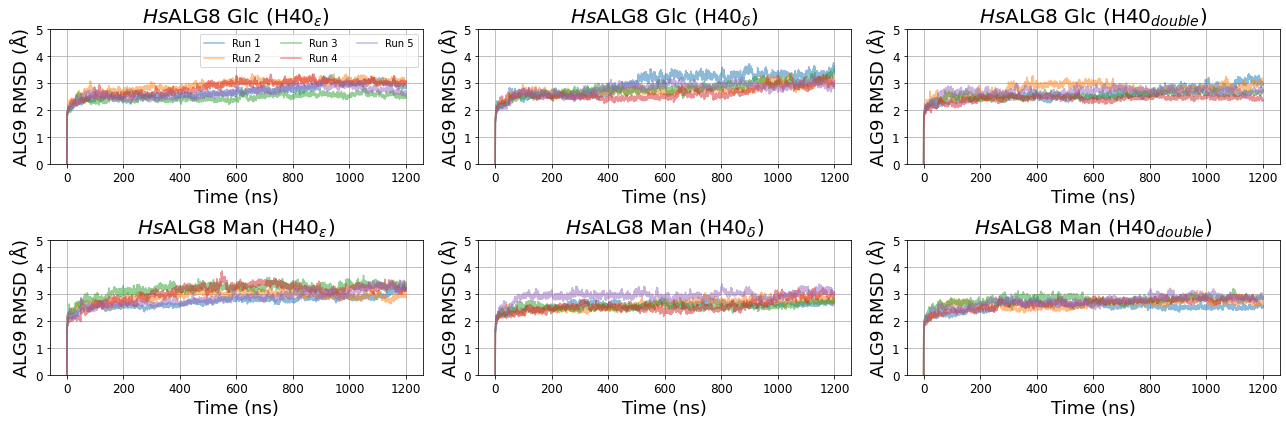

In [135]:
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.pro_rmsd
        x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.pro_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_xlabel('Time (ns)')
    ax.set_title(object_names[i_object_list])
    ax.set_ylabel(r'ALG9 RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_ALG8.svg'
plt.savefig(filename)

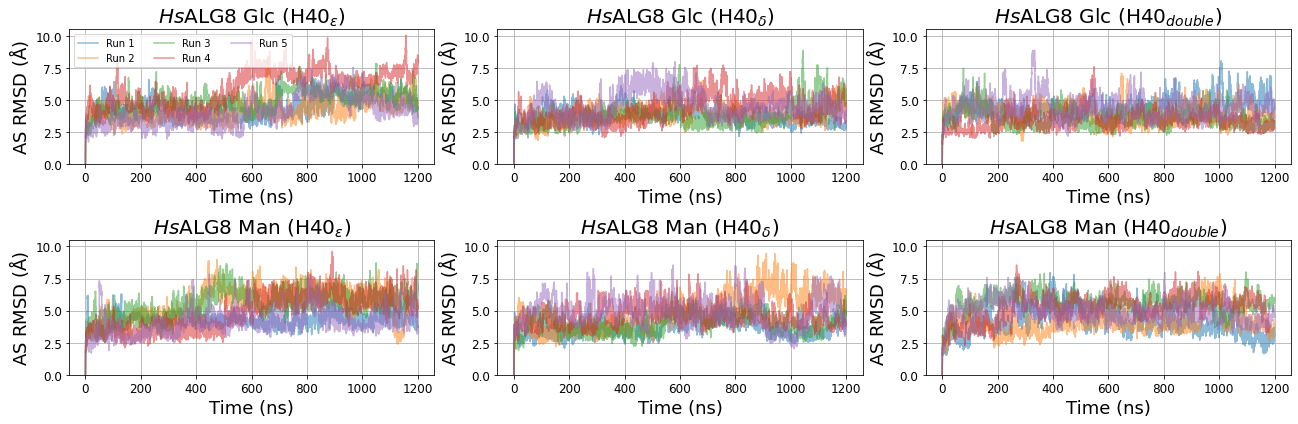

In [136]:
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10.5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsd[i_obj] = obj.AS_rmsd
        x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
        ax.plot(x,obj.AS_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'AS RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_AS.svg'
plt.savefig(filename)

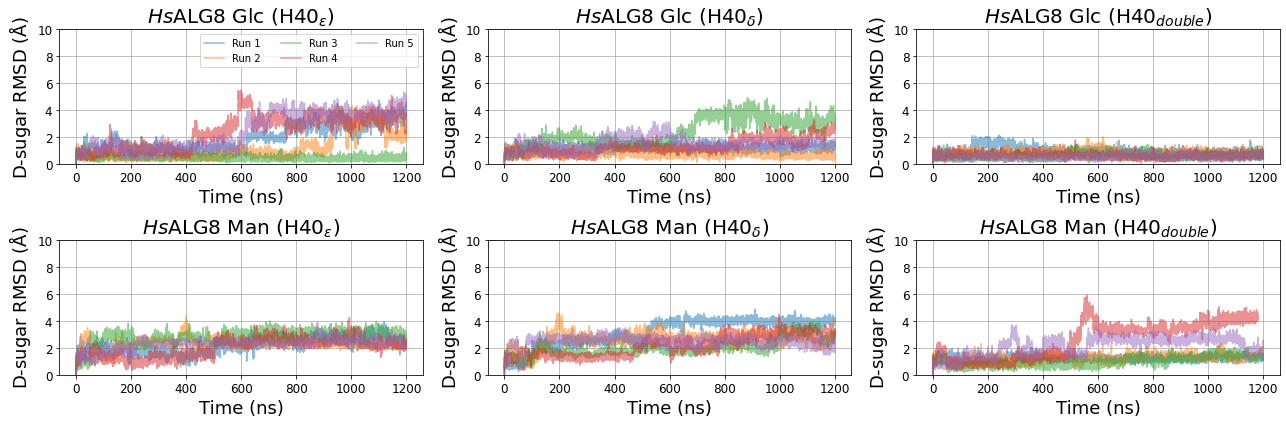

In [137]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.A_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'D-sugar RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

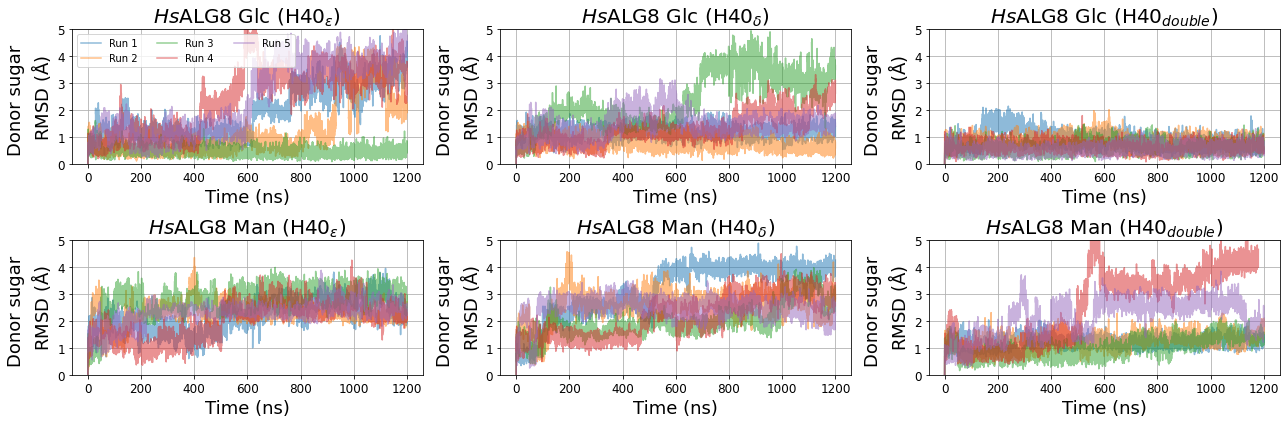

In [138]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,5]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.D_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.D_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Donor sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar.png'
plt.savefig(filename)

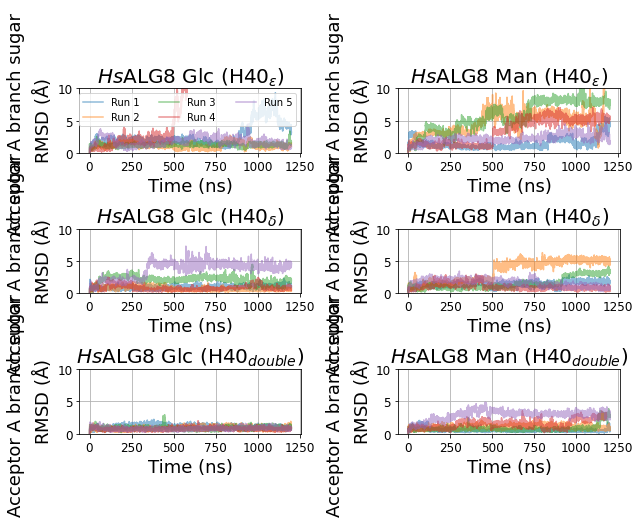

In [139]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(len(object_lists)//2, 2,figsize=(9,6))
ylim = [0,10]
for i_object_list, object_list in enumerate(object_lists):
    # ax = axs.flatten()[i_object_list]
    ax = axs.T.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.A_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.A_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor A branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Asugar.png'
plt.savefig(filename)

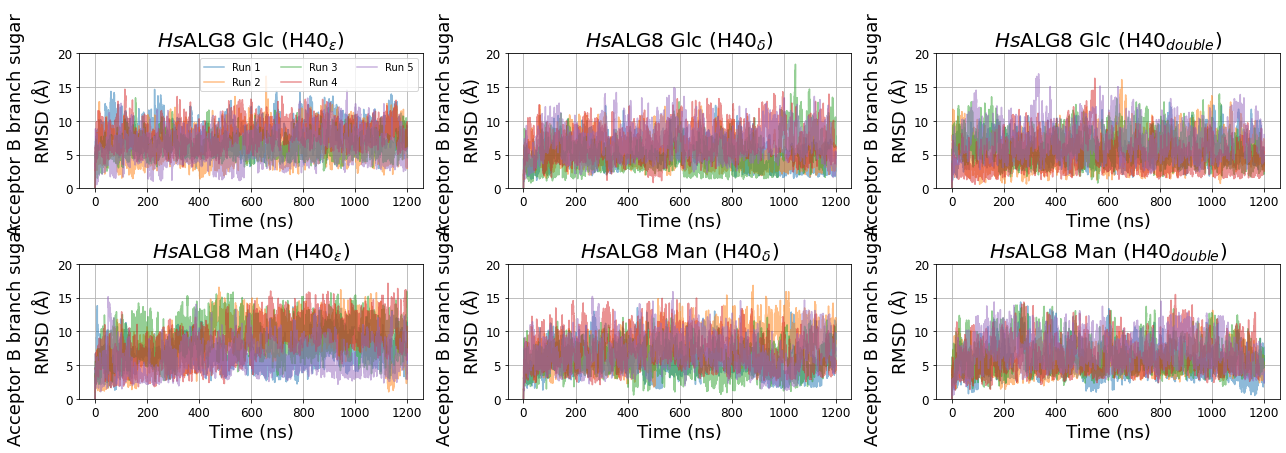

In [140]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,20]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.B_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.B_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor B branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Bsugar.png'
plt.savefig(filename)

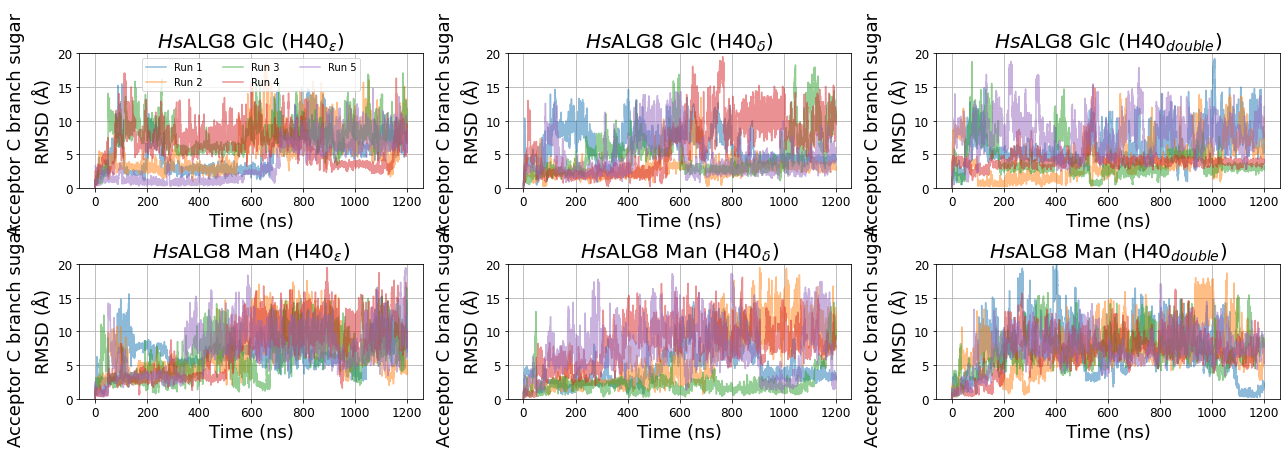

In [141]:
# Donor A-sugar RMSD
fig, axs = plt.subplots(2,len(object_lists)//2,figsize=(3*len(object_lists),6))
ylim = [0,20]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs.flatten()[i_object_list]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.C_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.C_sugar_rmsd, label = f'Run {i_obj+1}',alpha=0.5)
    if i_object_list == 0:
        ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i_object_list])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor C branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Csugar.png'
plt.savefig(filename)

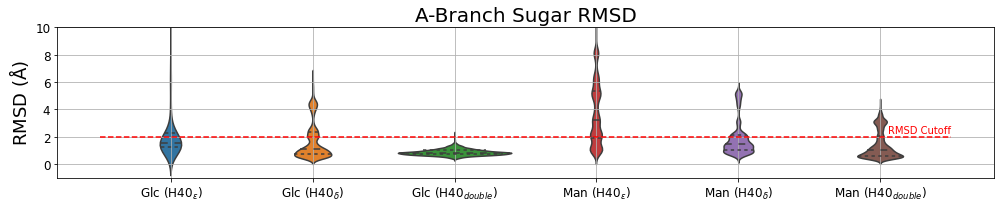

In [142]:
fig, axs = plt.subplots(1,1,figsize=(14,3))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0.1
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.A_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('A-Branch Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(-1,10)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Abranch_sugar_RMSD.png'
plt.savefig(filename)

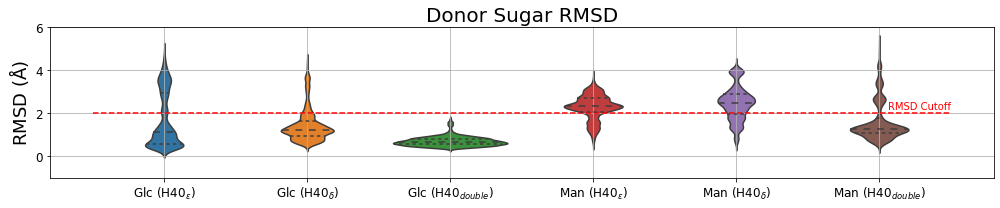

In [143]:
fig, axs = plt.subplots(1,1,figsize=(14,3))
rmsd_cutoff = 2.0
df = pd.DataFrame()
sliding_window = 10
discard_ratio = 0
for i_object_list, object_list in enumerate(object_lists):
    # violin plot for DP RMSD
    for i_obj, obj in enumerate(object_list):
        df_ = pd.DataFrame()
        df_['AS RMSD'] = sliding_average(obj.D_sugar_rmsd[int(len(obj.pro_rmsd)*discard_ratio):], window_size=sliding_window)
        df_['Object'] = ' '.join(object_names[i_object_list].split(' ')[1:])
        df_['Run'] = i_obj + 1
        df = pd.concat([df, df_], ignore_index=True)
sns.violinplot(x='Object', y='AS RMSD', data=df,  inner='quartile')
plt.hlines(rmsd_cutoff, -0.5, len(object_lists)-0.5, colors='r', linestyles='dashed', label='RMSD Cutoff')
plt.text(len(object_lists)-0.5, rmsd_cutoff+0.1, 'RMSD Cutoff', color='r', va='bottom', ha='right')
plt.title('Donor Sugar RMSD')
plt.ylabel(r'RMSD ($\rm \AA$)')
plt.ylim(-1,6)
plt.xlabel('')
plt.grid()
plt.tight_layout()
filename = figdir+'Violin_Donor_sugar_RMSD.png'
plt.savefig(filename)

## RMSF

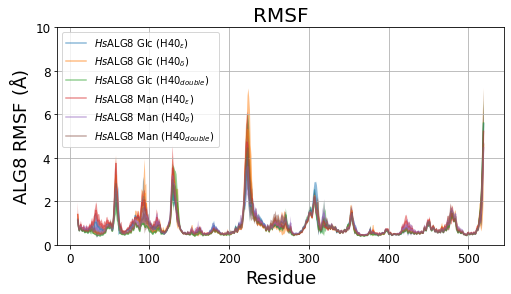

In [144]:
fig, axs = plt.subplots(1,1,figsize=(8,4))
ylim = [0,10]
resid_offset = 10
for i_object_list, object_list in enumerate(object_lists):
    rmsf = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        rmsf[i_obj] = obj.pro_rmsf[:,1]
    rmsf = np.array(rmsf)
    axs.plot(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset, rmsf.mean(axis=0), label = f'{object_names[i_object_list]}',alpha=0.5)
    axs.fill_between(np.arange(len(obj.pro_rmsf[:,0]))+resid_offset,rmsf.mean(axis=0)-rmsf.std(axis=0),rmsf.mean(axis=0)+rmsf.std(axis=0),alpha=0.5)
axs.grid()
axs.legend()
# axs.set_xlim([resid_offset, len(obj.protein_rmsf[:,0])+resid_offset])
axs.set_ylim(ylim)
axs.set_title('RMSF')
axs.set_xlabel('Residue')
axs.set_ylabel(r'ALG8 RMSF ($\rm \AA$)')
filename = figdir+'RMSF_ALG8.svg'
plt.savefig(filename)

# Active Geometry

In [145]:
suffixes = ['epsilon', 'delta', 'double']
binsize_r = 0.3
binsize_theta = 180/50
cmap = 'Blues'
discard = 4000 # 4000 frames for 800ns -> 500 frames for 100ns
log = False

/localhome/shuchen/.conda/envs/ALG8_pytraj/lib/python3.6/site-packages/ipykernel_launcher.py:23: UserWarning: Z contains NaN values. This may result in rendering artifacts.


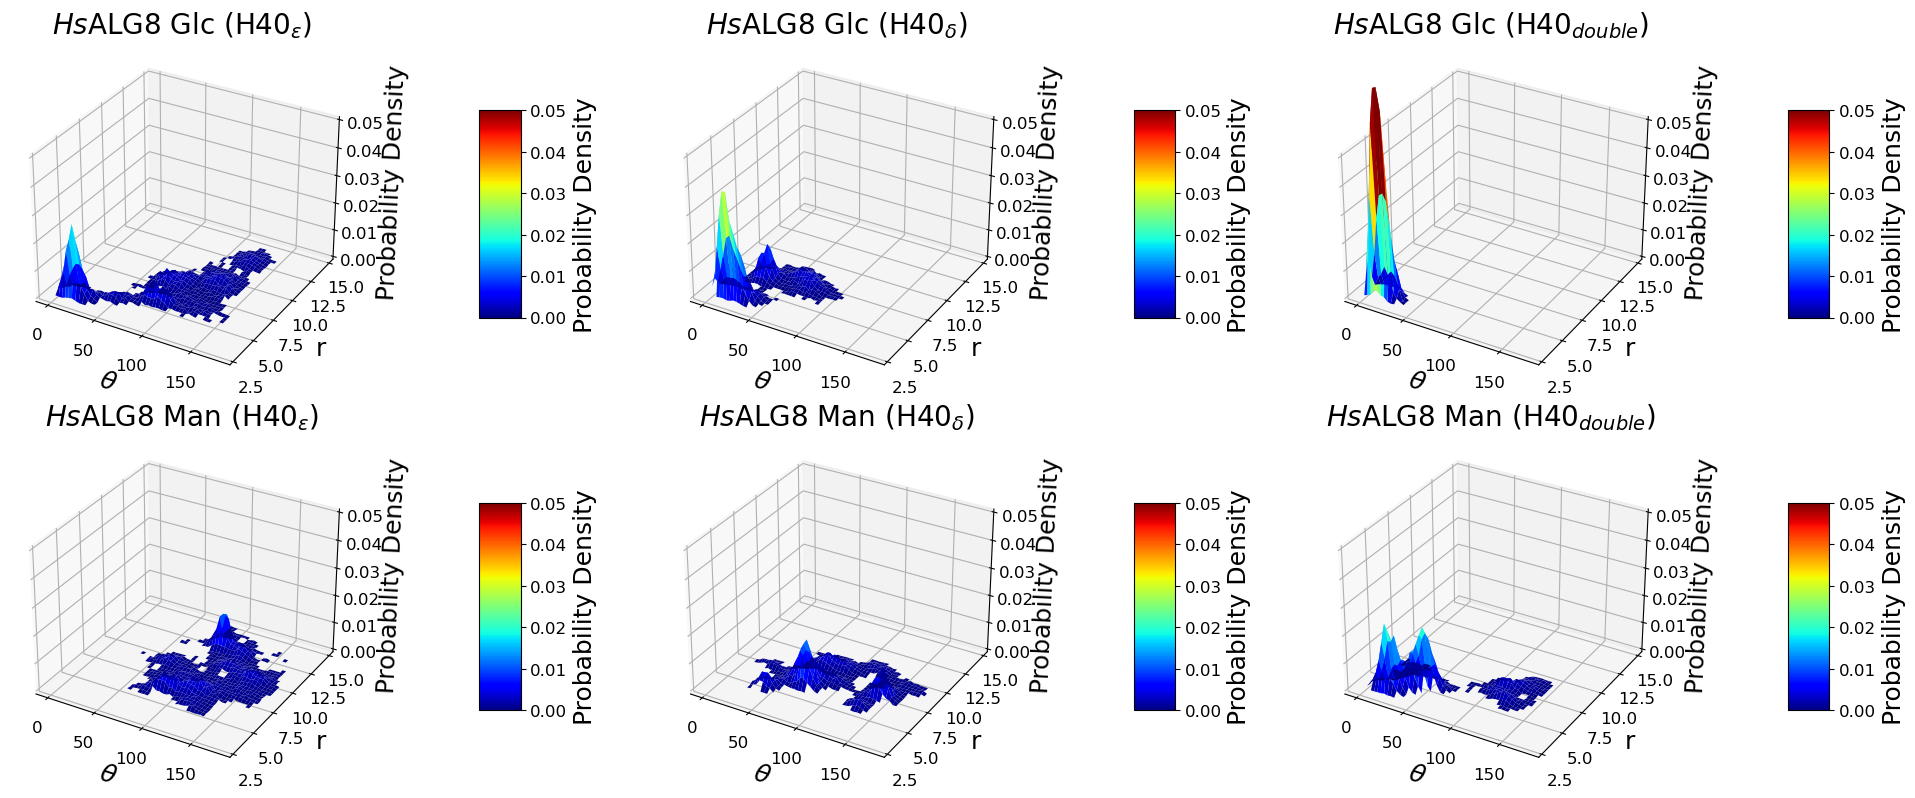

In [146]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(20,8),dpi=100)
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
    angle = np.concatenate([obj.acceptor_donor_angle[discard:] for obj in object_list])
    ax = fig.add_subplot(2,3,i+1 , projection='3d')
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    
    if log:
        H, _, _ = np.histogram2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=False)
        H = np.log(H+1)
    else:
        H, _, _ = np.histogram2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=True)
    H[H==0] = np.nan
    Theta, R = np.meshgrid(theta_edges, r_edges)
    Theta = 0.5 * (Theta[:-1,:-1] + Theta[1:,:-1])
    R = 0.5 * (R[:-1,:-1] + R[:-1,1:])
    im = ax.plot_surface(Theta, R, H, cmap=plt.cm.jet)
    # if i == 4:  
        # fig.colorbar(im, ax=ax, orientation='horizontal',label='Log Density',shrink=0.6)
    im.set_clim(0,0.05)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal',label='Density',shrink=0.4, aspect=5)
        
    ax.set_title(object_names[i])
    ax.set_zlim(0,0.05)
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'r')
    ax.set_zlabel('Probability Density')

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=0.6, aspect=5, pad=0.2)
plt.tight_layout()
filename = figdir+'Hbond_3D.svg'
plt.savefig(filename)


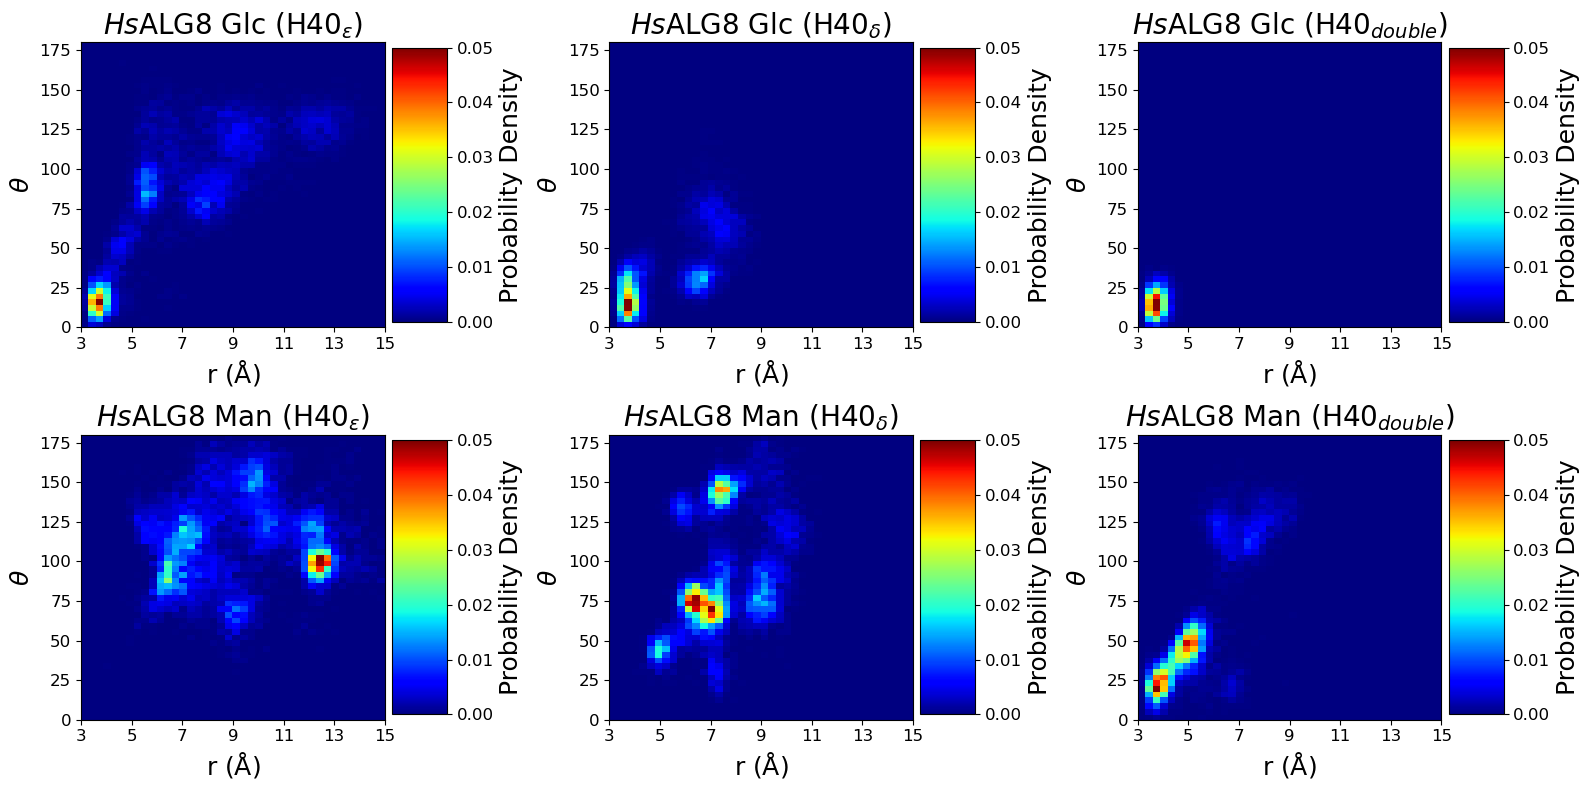

In [147]:
# fig = plt.figure(figsize=plt.figaspect(0.5))
fig = plt.figure(figsize=(16,8),dpi=100)
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
    angle = np.concatenate([obj.acceptor_donor_angle[discard:] for obj in object_list])
    ax = fig.add_subplot(2,3,i+1)
    # def plot_hbond_angle(self, ax,r,theta, cmap='Blues',log=False):
    # Plot the histogram in half polar coordinates
    binsize_r = 0.3
    binsize_theta = 180/50
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    ax.hist2d(acceptor_donor_distance,angle ,bins=(r_edges, theta_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i])
    ax.set_ylabel(r'$\theta$')
    ax.set_xlabel(r'r ($\rm \AA$)')
    ax.set_xticks(np.arange(3,16,2))

    fig.colorbar(im, ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
filename = figdir+'Hbond_2D_600ns.png'
plt.savefig(filename)


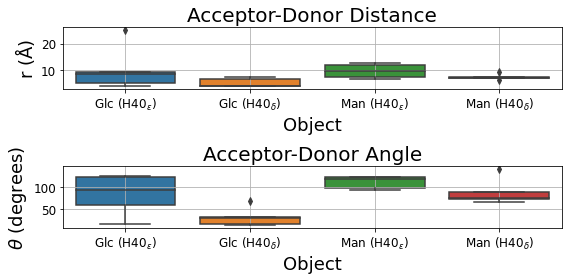

In [148]:
## Boxplot for the distance and angle
fig, axs = plt.subplots(2,1,figsize=(8,4))
df = pd.DataFrame()
for i, object_list in enumerate(object_lists):
    if i == 2 or i == 5:
        continue
    for i_obj in range(len(object_list)):
        obj = object_list[i_obj]
        df_ = pd.DataFrame([{
            'Distance': np.mean(obj.acceptor_donor_distance[discard:]),
            'Angle': np.mean(obj.acceptor_donor_angle[discard:]),
            'Object': ' '.join(object_names[i].split(' ')[1:]),
            'Run': i_obj + 1
        }])
        df = pd.concat([df, df_], ignore_index=True)
sns.boxplot(x='Object', y='Distance', data=df, ax=axs[0])
sns.boxplot(x='Object', y='Angle', data=df, ax=axs[1])
axs[0].grid()
axs[1].grid()
axs[0].set_title('Acceptor-Donor Distance')
axs[0].set_ylabel(r'r ($\rm \AA$)')
axs[1].set_title('Acceptor-Donor Angle')
axs[1].set_ylabel(r'$\theta$ (degrees)')
plt.tight_layout()
filename = figdir+'Boxplot_distance_angle.png'
plt.savefig(filename)

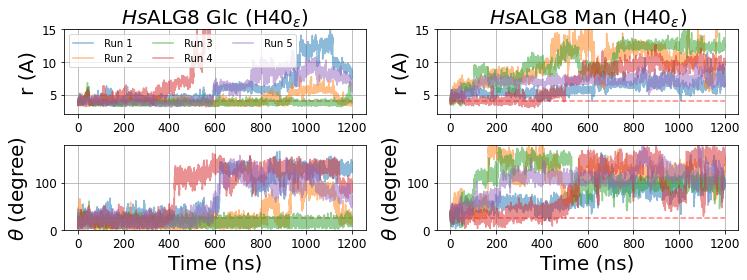

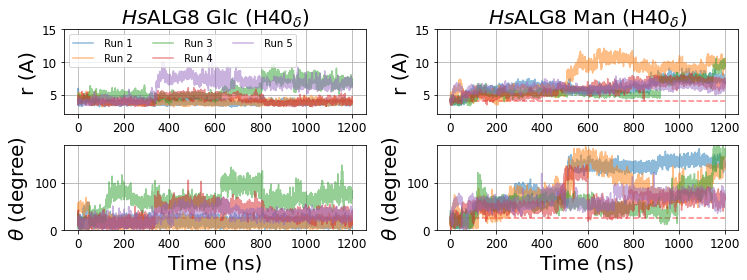

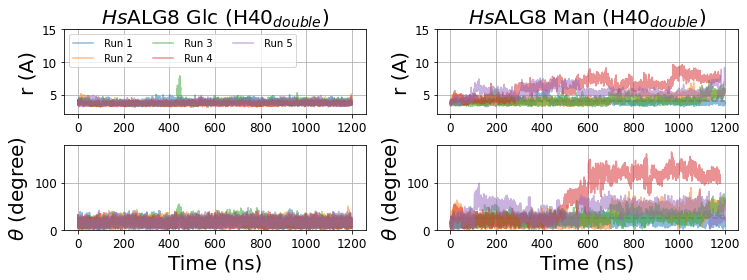

In [149]:
# 1D plots and saving
r_line = 4.0
theta_line = 25
for offset in range(3):
    fig, axs = plt.subplots(2, 2, figsize=(10.5,4))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        # ax3 = axs[2,i]
        for obj in object_list:
            x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)
            ax1.plot(x,obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.5)
            ax2.plot(x,obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
            # ax3.plot(x,obj.donor_bending_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.5, linestyle='-')
        if i == 0:
            ax1.legend(ncol=3, loc='upper left')
        ax1.set_ylim([2,15])
        ax2.set_ylim([0,180])
        # ax3.set_ylim([110,180])
        ax1.hlines(r_line, 0, x[-1], color='r', linestyle='--', alpha=0.5)
        ax2.hlines(theta_line, 0, x[-1], color='r', linestyle='--', alpha=0.5)
        ax1.set_title(object_names[show_idx[i]])
        ax1.set_ylabel('r (A)', fontsize=20)
        ax2.set_ylabel(r'$\theta$ (degree)', fontsize=20)
        # ax3.set_ylabel(r'$\theta^{1,4}_{sugar}$', fontsize=20)
        ax2.set_xlabel('Time (ns)', fontsize=20)
        ax1.grid()
        ax2.grid()
        # ax3.grid()
    plt.tight_layout()
    filename = figdir+f'1D_r_theta_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)


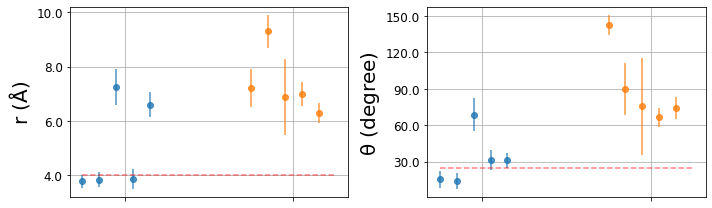

In [150]:
## Boxplot for the distance and angle
substrate_titles = ['Dol25-P-Glc', 'Dol25-P-Man']

fig, axs = plt.subplots(1, 2, figsize=(10,3))
width = 0.1
for i, object_list in enumerate(object_lists):
    if i not in [1, 4]:
        continue
    base_position = - width if 'Glc' in object_names[i] else width
    legend = 'Glc' if 'Glc' in object_names[i] else 'Man'
    for i_obj in range(len(object_list)):
        obj = object_list[i_obj]
        avg1 = np.mean(obj.acceptor_donor_distance[discard:])
        std1 = np.std(obj.acceptor_donor_distance[discard:])
        avg2 = np.mean(obj.acceptor_donor_angle[discard:])
        std2 = np.std(obj.acceptor_donor_angle[discard:])
        position = base_position + (i_obj - len(object_list)/2)*width/len(object_list)
        axs[0].errorbar(position, avg1, yerr=std1, fmt='o', label=legend if i_obj == 0 else "", color='C0' if 'Glc' in object_names[i] else 'C1', alpha=0.8)
        axs[1].errorbar(position, avg2, yerr=std2, fmt='o', color='C0' if 'Glc' in object_names[i] else 'C1', alpha=0.8)
        
ylabels = [r'r $\rm (\AA)$', r'$\rm \theta$ (degree) ']
for i_ax, ax in enumerate(axs):
    ax.set_ylabel(ylabels[i_ax], fontsize=20)
    yticks = np.linspace(0, 10, 6) if i_ax == 0 else np.linspace(0, 180, 7)
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=12)
    ax.grid()
    ax.set_xticks([ -width, width])
    # ax.set_xticklabels(['Glc','Man'], fontdict={'fontsize': 20})
    # xticklabels = [' '.join(object_names[1].split()[:2] + ['\n'] + [object_names[1].split()[2]]),
    #                ' '.join(object_names[4].split()[:2] + ['\n'] + [object_names[4].split()[2]])]
    xticklabels = ['', ''] 
    ax.set_xticklabels(xticklabels, fontdict={'fontsize': 20})

axs[0].hlines(r_line, -1.5*width, 1.5*width, color='r', linestyle='--', alpha=0.5)
axs[1].hlines(theta_line, -1.5*width, 1.5*width, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
filename = figdir+'replicates_plot_r_theta_H40delta_no_xlabels.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')

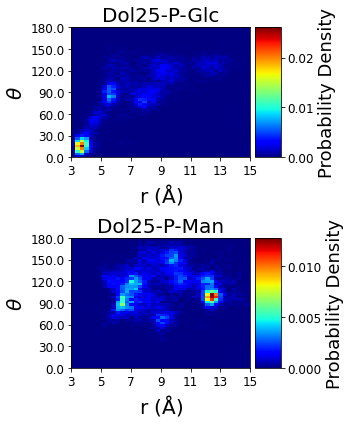

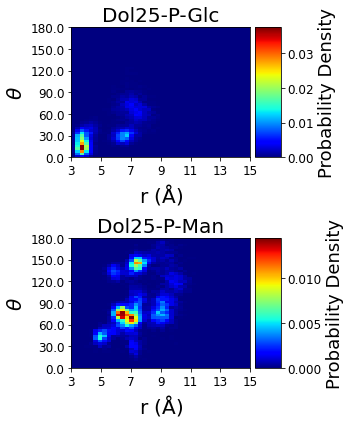

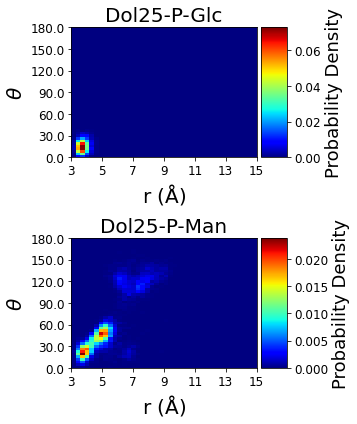

In [151]:
# 2D plots and saving
substrate_titles = ['Dol25-P-Glc', 'Dol25-P-Man']
for offset in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(5,6))
    show_idx = [offset, offset+3]

    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax = axs[i]
        distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
        angle = np.concatenate([obj.acceptor_donor_angle[discard:] for obj in object_list])
        r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
        theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
        im = ax.hist2d(distance,angle ,bins=(r_edges, theta_edges),density=True,cmap=plt.cm.jet)
        # title = 'Glc' if 'Glc' in object_names[show_idx[i]] else 'Man'
        # ax.set_title(title, fontsize=20)
        # ax.set_title(object_names[i*3+offset], fontsize=20)
        ax.set_title(substrate_titles[i], fontsize=20)
        ax.set_ylabel(r'$\theta$', fontsize=20)
        ax.set_xlabel(r'r ($\rm \AA$)', fontsize=20)
        ax.set_xticks(np.arange(3,16,2))
        ax.set_xticklabels(np.arange(3,16,2), fontsize=12)
        ax.set_yticks(np.linspace(0, 180, 7))
        ax.set_yticklabels(np.linspace(0, 180, 7), fontsize=12)

        fig.colorbar(im[3], ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
    plt.tight_layout()
    filename = figdir+f'2D_r_theta_angle_{suffixes[offset]}_with_titles.png'
    plt.savefig(filename, dpi=300)



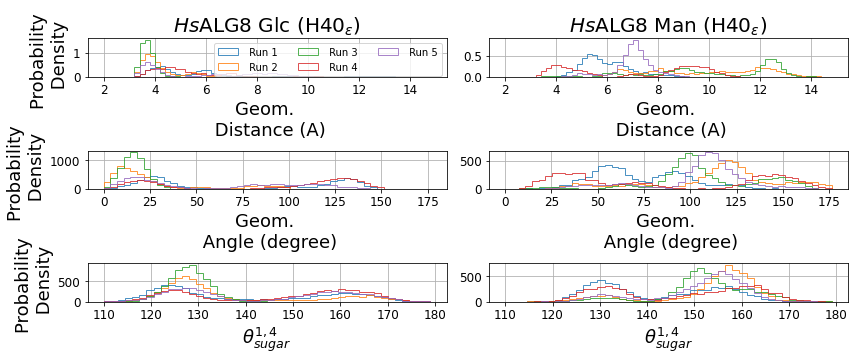

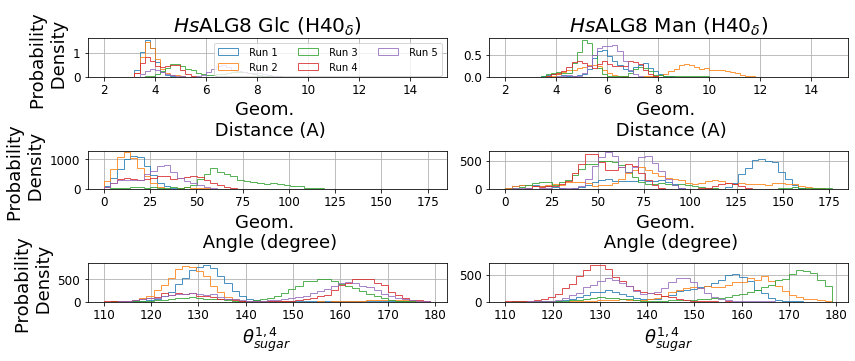

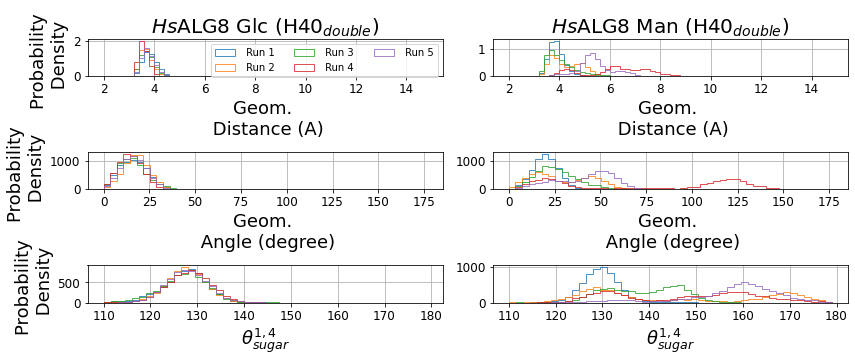

In [152]:
# 1D plots and saving
for offset in range(3):
    fig, axs = plt.subplots(3, 2, figsize=(12,5))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        ax3 = axs[2,i]
        bin1 = np.arange(2,15,0.2)
        bin2 = np.arange(0,180,3.6)
        bin3 = np.arange(110,180,1.5)
        for obj in object_list:
            ax1.hist(obj.acceptor_donor_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.8, bins=bin1, density=True, histtype='step')
            ax2.hist(obj.acceptor_donor_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin2, histtype='step')
            ax3.hist(obj.donor_bending_angle, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-', bins=bin3, histtype='step')
        if i == 0:
            ax1.legend(ncol=3, loc='upper right')
        ax1.set_title(object_names[i*3+offset])
        ax1.set_xlabel('Geom. \n Distance (A)')
        ax2.set_xlabel('Geom. \n Angle (degree)')
        ax3.set_xlabel(r'$\theta^{1,4}_{sugar}$')
        if i == 0 or i ==3:
            ax1.set_ylabel('Probability \n Density')
            ax2.set_ylabel('Probability \n Density')
            ax3.set_ylabel('Probability \n Density')
        ax1.grid()
        ax2.grid()
        ax3.grid()
    plt.tight_layout()
    filename = figdir+f'1D_r_theta_{suffixes[offset]}_distribution.png'
    plt.savefig(filename, dpi=300)


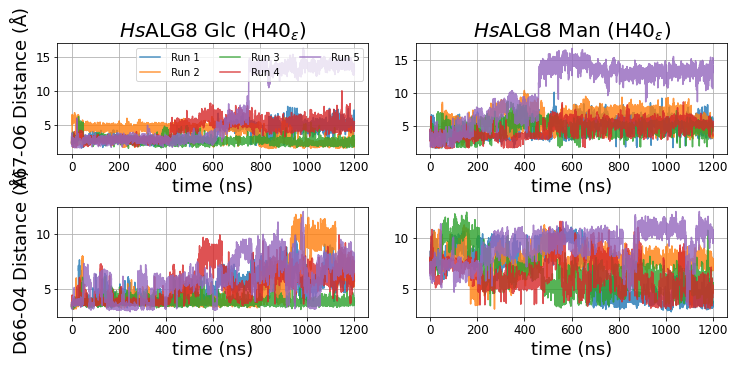

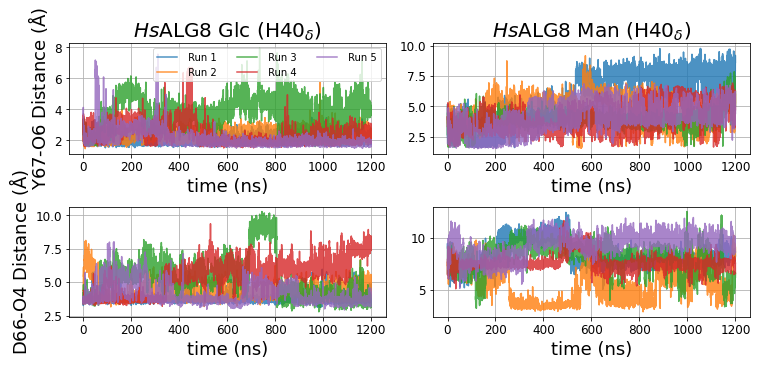

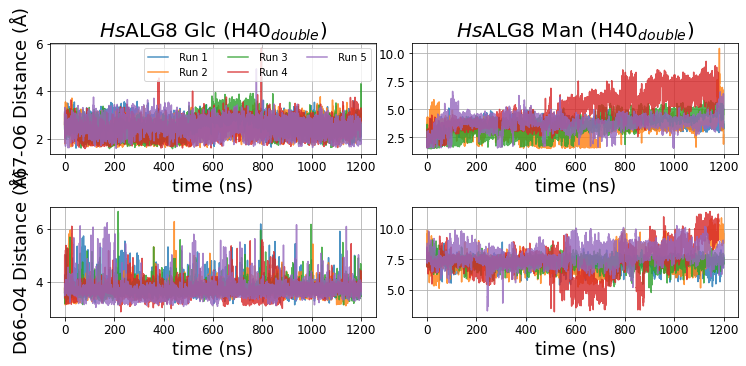

In [153]:
# 1D plots and saving
for offset in range(3):
    fig, axs = plt.subplots(2, 2, figsize=(10.5,5))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        
        for obj in object_list:
            x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)
            ax1.plot(x, obj.Y67_O6_distance, label = f' Run {object_list.index(obj)+1}',alpha=0.8)
            ax2.plot(x, obj.D66_O4_distance, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-')
        if i == 0:
            ax1.legend(ncol=3, loc='upper right')
        ax1.set_title(object_names[i*3+offset])
        ax1.set_xlabel('time (ns)')
        ax2.set_xlabel('time (ns)')
        if i == 0 or i ==3:
            ax1.set_ylabel(r'Y67-O6 Distance ($\rm \AA$)')
            ax2.set_ylabel(r'D66-O4 Distance ($\rm \AA$)')
        ax1.grid()
        ax2.grid()
    plt.tight_layout()
    filename = figdir+f'1D_distance_Y67_D66_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)


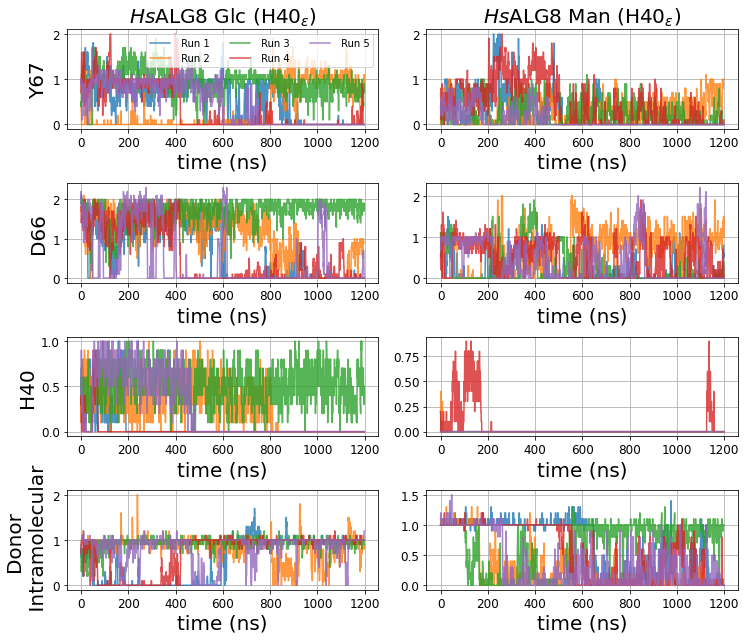

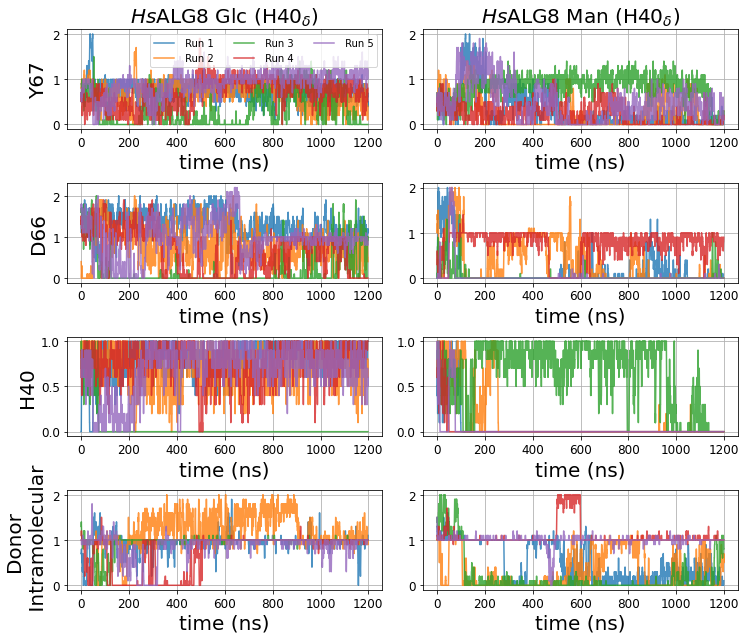

In [154]:
# 1D plots and saving
window_size = 10
ys = ['Y67', 'D66', 'H40', 'Donor \n Intramolecular']

for offset in range(2):
    fig, axs = plt.subplots(4, 2, figsize=(10.5,9))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        ax3 = axs[2,i]
        ax4 = axs[3,i]
        for obj in object_list:
            x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)[:len(obj.pro_rmsd)-window_size+1]
            y1 = sliding_average(obj.protein_substrates_bonds[1,11], window_size=window_size)
            y2 = sliding_average(obj.protein_substrates_bonds[1,6], window_size=window_size)
            y3 = sliding_average(obj.protein_substrates_bonds[1,7], window_size=window_size)
            y4 = sliding_average(obj.intra_hydrogen_bonds[1][1], window_size=window_size)
            ax1.plot(x, y1, label = f' Run {object_list.index(obj)+1}',alpha=0.8)
            ax2.plot(x, y2, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-')
            ax3.plot(x, y3, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-')
            ax4.plot(x, y4, label = f'Run {object_list.index(obj)+1}',alpha=0.8, linestyle='-')
        if i == 0:
            ax1.legend(ncol=3, loc='upper right')
        ax1.set_title(object_names[i*3+offset], fontsize=20)
        ax1.set_xlabel('time (ns)', fontsize=20)
        ax2.set_xlabel('time (ns)', fontsize=20)
        ax3.set_xlabel('time (ns)', fontsize=20)
        ax4.set_xlabel('time (ns)', fontsize=20)
        if i == 0 or i ==3:
            ax1.set_ylabel(ys[0], fontsize=20)
            ax2.set_ylabel(ys[1], fontsize=20)
            ax3.set_ylabel(ys[2], fontsize=20)
            ax4.set_ylabel(ys[3], fontsize=20)
        ax1.grid()
        ax2.grid()
        ax3.grid()
        ax4.grid()
    plt.tight_layout()
    filename = figdir+f'1D_Hbond_{suffixes[offset]}.png'
    plt.savefig(filename, dpi=300)

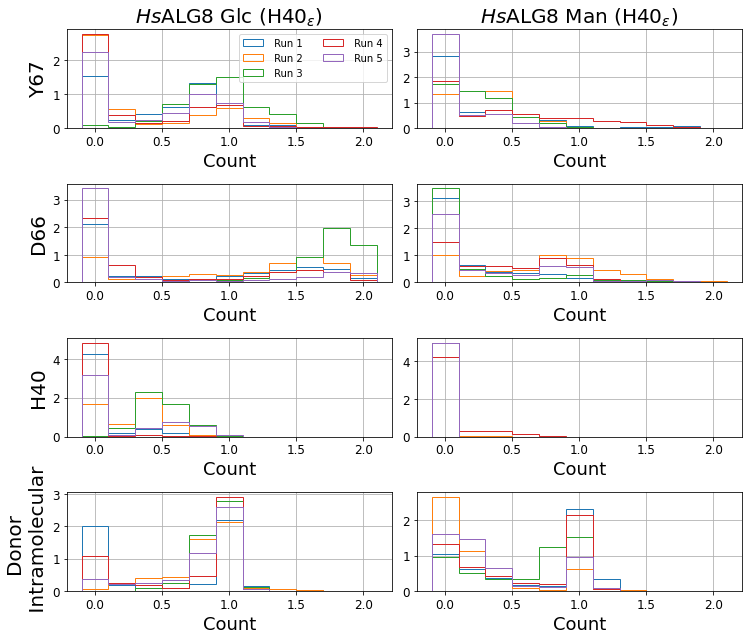

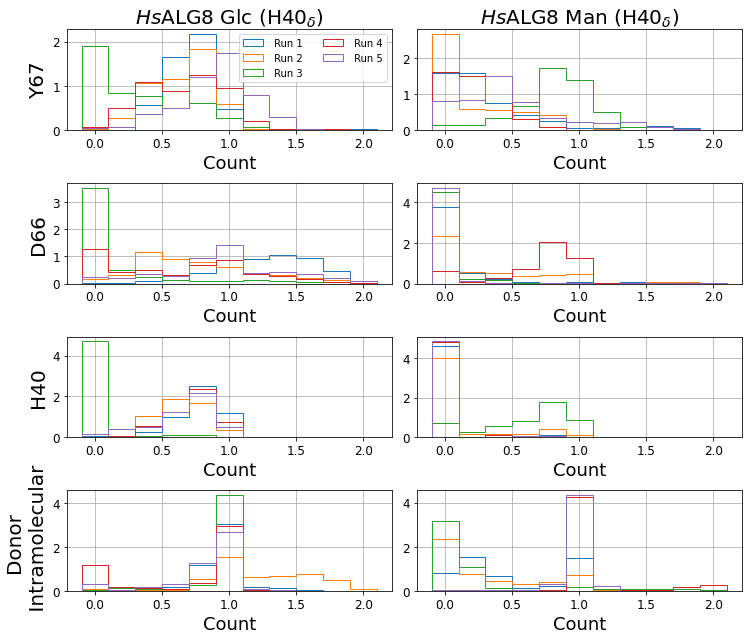

In [155]:
# 1D plots and saving
window_size = 10
ys = ['Y67', 'D66', 'H40', 'Donor \n Intramolecular']
bins = np.linspace(-0.1,2.1,12)
for offset in range(2):
    fig, axs = plt.subplots(4, 2, figsize=(10.5,9))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        ax3 = axs[2,i]
        ax4 = axs[3,i]
        for obj in object_list:
            # x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)[:len(obj.pro_rmsd)-window_size+1]
            y1 = sliding_average(obj.protein_substrates_bonds[1,11], window_size=window_size)
            y2 = sliding_average(obj.protein_substrates_bonds[1,6], window_size=window_size)
            y3 = sliding_average(obj.protein_substrates_bonds[1,7], window_size=window_size)
            y4 = sliding_average(obj.intra_hydrogen_bonds[1][1], window_size=window_size)
            ax1.hist(y1, bins=bins, label = f' Run {object_list.index(obj)+1}', density=True, histtype='step')
            ax2.hist(y2, bins=bins,label = f'Run {object_list.index(obj)+1}', linestyle='-', density=True, histtype='step') 
            ax3.hist(y3, bins=bins,label = f'Run {object_list.index(obj)+1}', linestyle='-', density=True, histtype='step')
            ax4.hist(y4, bins=bins,label = f'Run {object_list.index(obj)+1}', linestyle='-', density=True, histtype='step')
        if i == 0:
            ax1.legend(ncol=2, loc='upper right')
        ax1.set_title(object_names[i*3+offset], fontsize=20)
        for ax in axs[:,i]:
            ax.set_xlabel('Count')
        if i == 0 or i ==3:
            ax1.set_ylabel(ys[0], fontsize=20)
            ax2.set_ylabel(ys[1], fontsize=20)
            ax3.set_ylabel(ys[2], fontsize=20)
            ax4.set_ylabel(ys[3], fontsize=20)
        ax1.grid()
        ax2.grid()
        ax3.grid()
        ax4.grid()
    plt.tight_layout()
    filename = figdir+f'1D_Hbond_{suffixes[offset]}_hist.png'
    plt.savefig(filename, dpi=300)

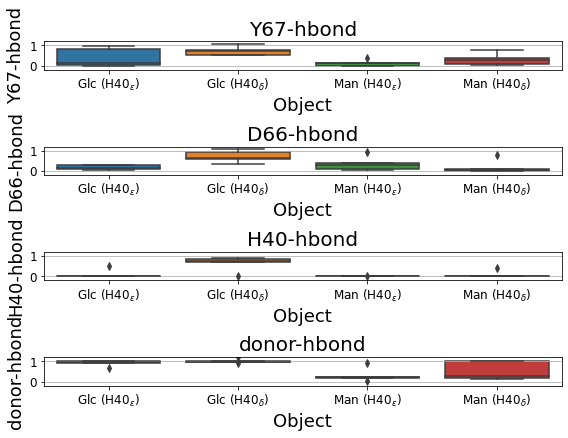

In [156]:
## Boxplot for the distance and angle
fig, axs = plt.subplots(4,1,figsize=(8,6))
df = pd.DataFrame()
for i, object_list in enumerate(object_lists):
    if i == 2 or i == 5:
        continue
    for i_obj in range(len(object_list)):
        obj = object_list[i_obj]
        df_ = pd.DataFrame([{
            # 'Y67-O6': np.mean(obj.Y67_O6_distance[discard:]),
            # 'D66-O4': np.mean(obj.D66_O4_distance[discard:]),
            'Y67-hbond' : np.mean(obj.protein_substrates_bonds[1,11][discard:]),
            'D66-hbond' : np.mean(obj.protein_substrates_bonds[1,6][discard:]),
            'H40-hbond' : np.mean(obj.protein_substrates_bonds[1,7][discard:]),
            'donor-hbond': np.mean(obj.intra_hydrogen_bonds[1][1][discard:]),
            'Object': ' '.join(object_names[i].split(' ')[1:]),
            'Run': i_obj + 1
        }])
        df = pd.concat([df, df_], ignore_index=True)
ys = ['Y67-hbond', 'D66-hbond', 'H40-hbond', 'donor-hbond']
for i_ax in range(4):
    axs[i_ax].grid()
    axs[i_ax].set_ylim(-0.2,1.2)
    axs[i_ax].set_title(ys[i_ax])
    axs[i_ax].set_ylabel('Count')
    sns.boxplot(x='Object', y=ys[i_ax], data=df, ax=axs[i_ax])
plt.tight_layout()
filename = figdir+'Boxplot_Hbonds.png'
plt.savefig(filename, dpi=300)

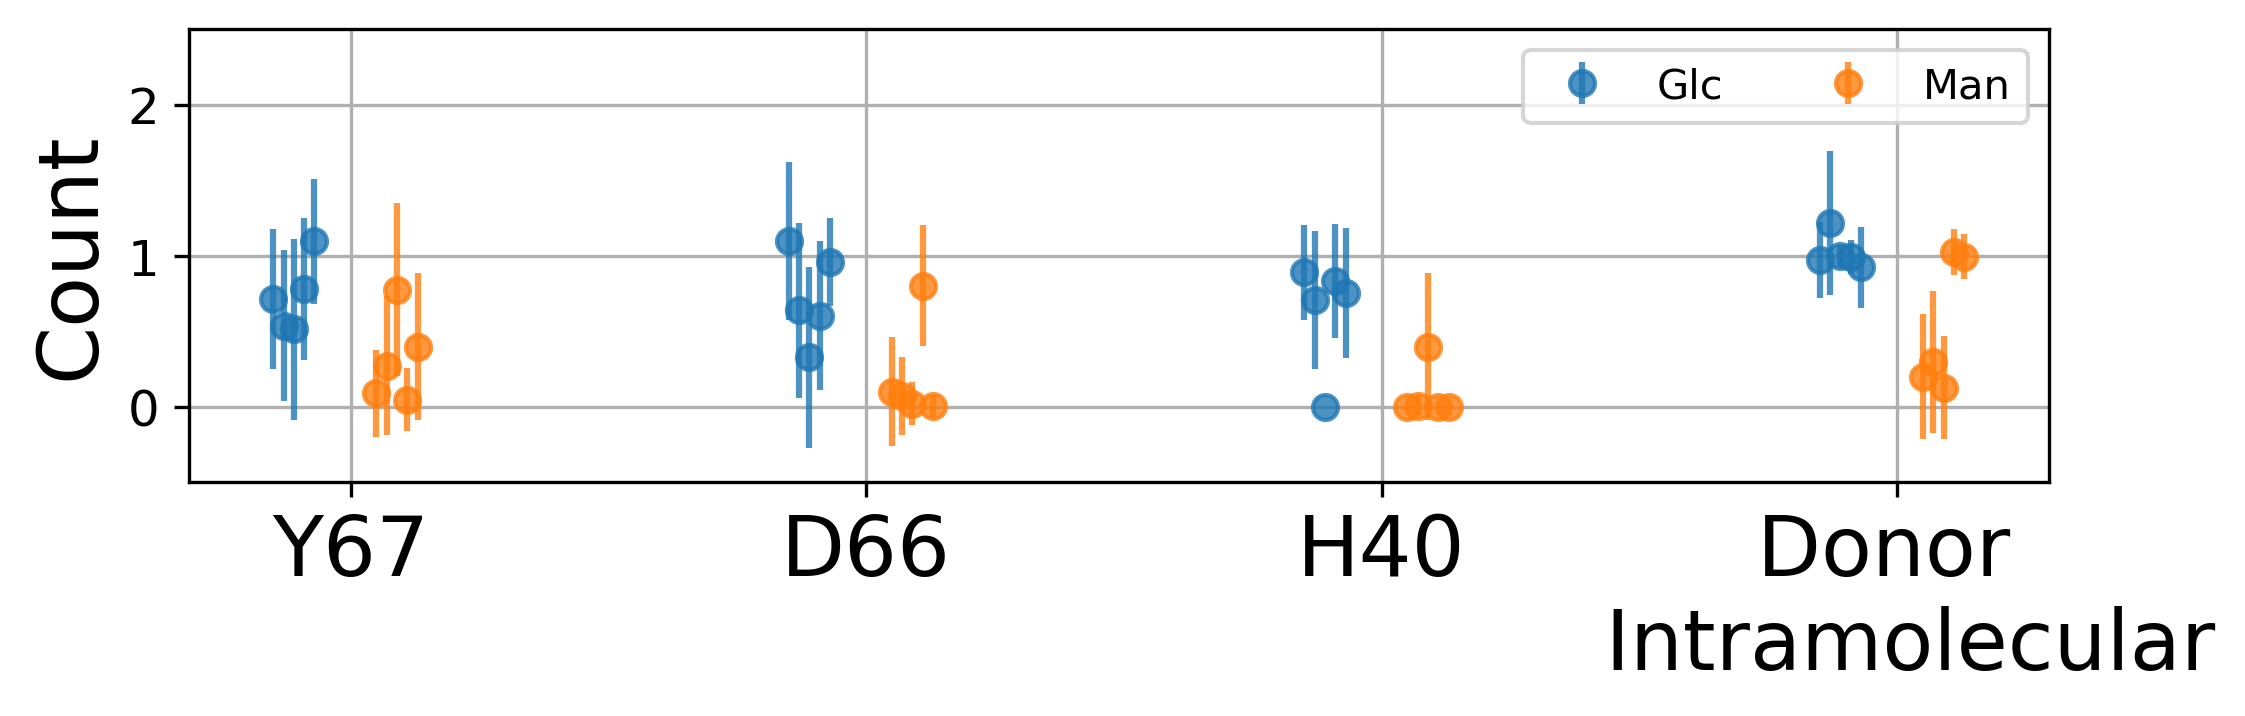

In [157]:
## Boxplot for the distance and angle
fig, ax = plt.subplots(1,1,figsize=(8,2), dpi=300)
resids = [11, 6, 7]
width = 0.1
xs = ['Y67', 'D66', 'H40', 'Donor \n Intramolecular']
for i, object_list in enumerate(object_lists):
    if i == 2 or i == 5 or i == 0 or i == 3:
        continue
    base_position = - width if 'Glc' in object_names[i] else width
    legend = 'Glc' if 'Glc' in object_names[i] else 'Man'
    for i_obj in range(len(object_list)):
        obj = object_list[i_obj]
        for i_resid, resid in enumerate(resids):
            avg = np.mean(obj.protein_substrates_bonds[1,resid][discard:])
            std = np.std(obj.protein_substrates_bonds[1,resid][discard:])
            position = i_resid + base_position + (i_obj - len(object_list)/2)*width/len(object_list)
            if resid == resids[0]:
                ax.errorbar(position, avg, yerr=std, fmt='o', label=legend if i_obj == 0 else "", color='C0' if 'Glc' in object_names[i] else 'C1', alpha=0.8)
            else:
                ax.errorbar(position, avg, yerr=std, fmt='o', color='C0' if 'Glc' in object_names[i] else 'C1', alpha=0.8)
        avg = np.mean(obj.intra_hydrogen_bonds[1][1][discard:])
        std = np.std(obj.intra_hydrogen_bonds[1][1][discard:])
        position = len(resids) + base_position + (i_obj - len(object_list)/2)*width/len(object_list)
        ax.errorbar(position, avg, yerr=std, fmt='o', color='C0' if 'Glc' in object_names[i] else 'C1', alpha=0.8)
            
# for i_ax in range(4):
ax.grid()
ax.set_ylim(-0.5,2.5)

plt.legend(ncol=2)
ax.set_ylabel('Count', fontsize=20)
ax.set_xticks(np.arange(0, len(xs)))
ax.set_xticklabels(xs, fontsize=20)
ax.set_xlabel('')
filename = figdir+'replicates_plot_Hbonds_H40delta.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')

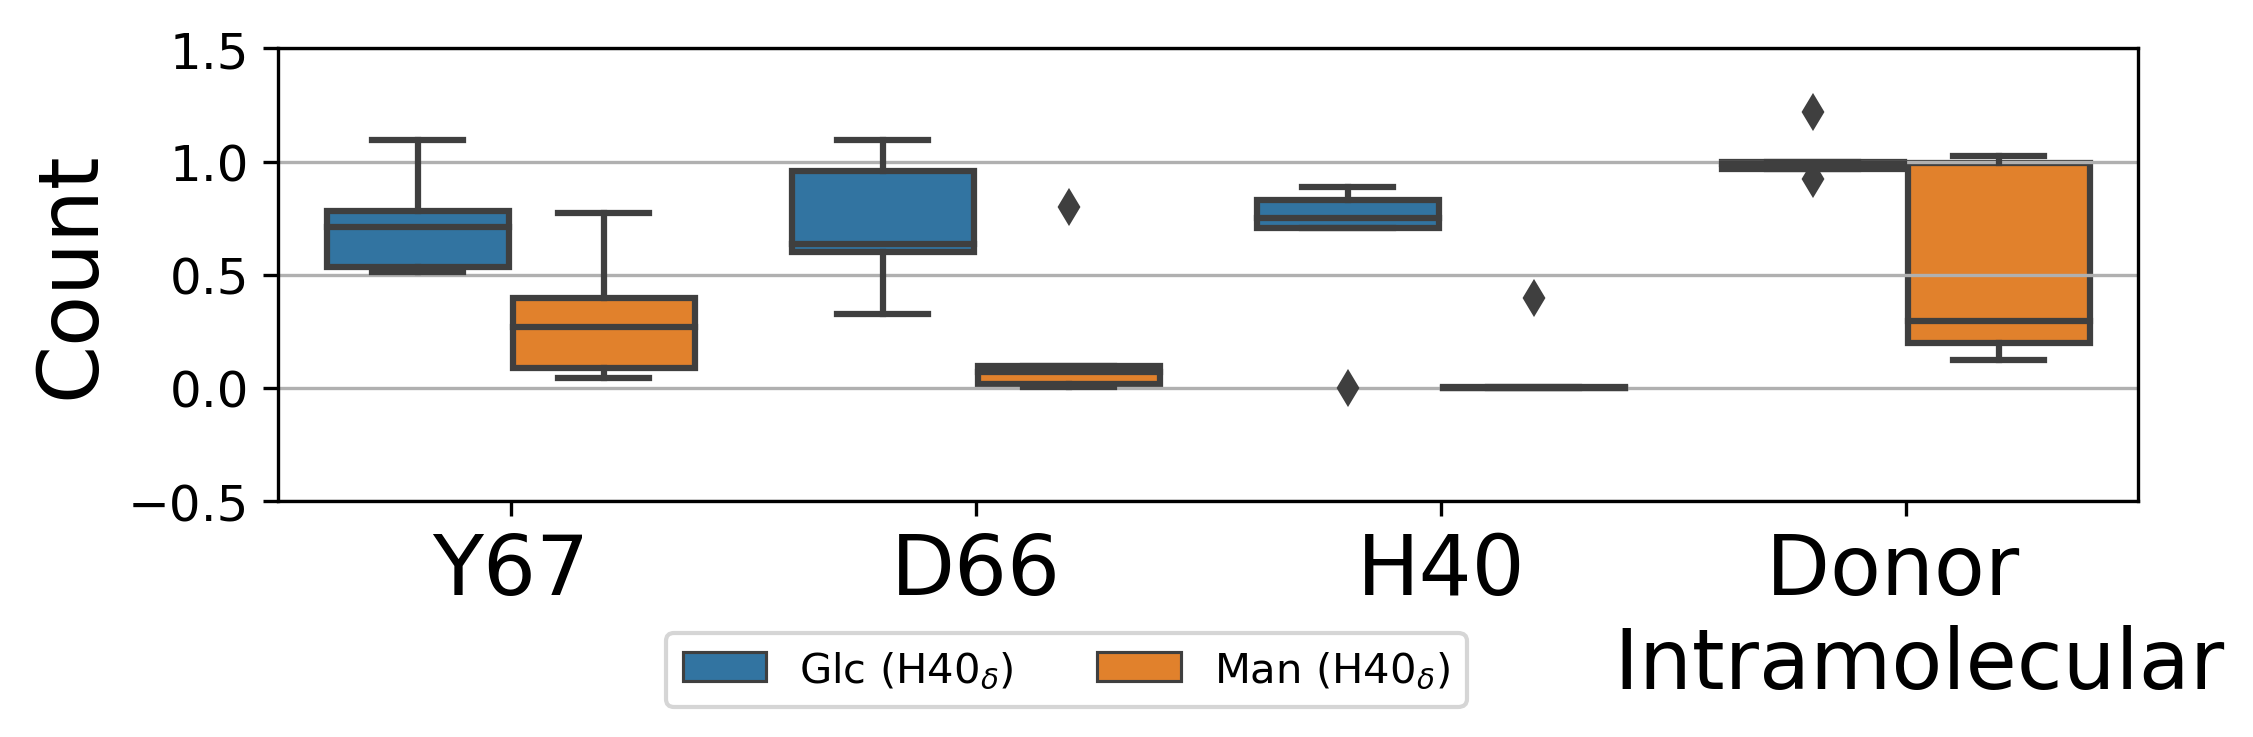

In [158]:
## Boxplot for the distance and angle
fig, ax = plt.subplots(1,1,figsize=(8,2), dpi=300)
xs = ['Y67', 'D66', 'H40', 'Donor \n Intramolecular']
df = pd.DataFrame()
for i, object_list in enumerate(object_lists):
    if i == 2 or i == 5 or i == 0 or i == 3:
        continue
    for i_obj in range(len(object_list)):
        obj = object_list[i_obj]
        data = [ np.mean(obj.protein_substrates_bonds[1,11][discard:]),
                 np.mean(obj.protein_substrates_bonds[1,6][discard:]),
                 np.mean(obj.protein_substrates_bonds[1,7][discard:]),
                 np.mean(obj.intra_hydrogen_bonds[1][1][discard:])]
        for id, d in enumerate(data):    
            df_ = pd.DataFrame([{
                'data' : d,
                'name' : xs[id],
                'Object': ' '.join(object_names[i].split(' ')[1:]),
                'Run': i_obj + 1
            }])
            df = pd.concat([df, df_], ignore_index=True)
# for i_ax in range(4):
ax.grid()
ax.set_ylim(-0.5,1.5)

sns.boxplot(x='name', y='data', hue='Object', data=df, ax=ax)
plt.legend(loc='lower right', title='', bbox_to_anchor=(0.65, -0.5), ncol=2)
ax.set_ylabel('Count', fontsize=20)
ax.set_xticklabels(xs, fontsize=20)
ax.set_xlabel('')
# plt.tight_layout()
filename = figdir+'Boxplot_Hbonds.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')

# H40 Delta wihtout Acceptor leaving

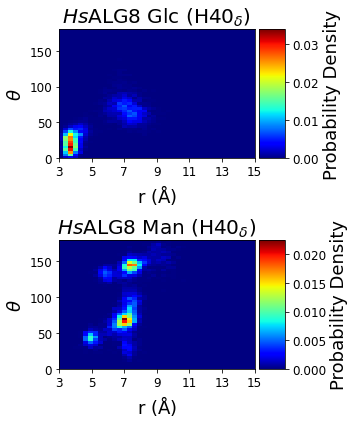

In [159]:
# 2D plots and saving
offset = 1
acceptor_leave_idx = [4, 1]
fig, axs = plt.subplots(2, 1, figsize=(5,6))
show_idx = [offset, offset+3]

for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
    ax = axs[i]
    distance = np.concatenate([obj.acceptor_donor_distance[discard:] for j, obj in enumerate(object_list) if j not in acceptor_leave_idx])
    angle = np.concatenate([obj.acceptor_donor_angle[discard:] for j, obj in enumerate(object_list) if j not in acceptor_leave_idx])
    r_edges     = np.arange(3,15+0.1*binsize_r,binsize_r)
    theta_edges = np.arange(0,180+0.01*binsize_theta,binsize_theta)
    im = ax.hist2d(distance,angle ,bins=(r_edges, theta_edges),density=True,cmap=plt.cm.jet)
    ax.set_title(object_names[i*3+offset])
    ax.set_ylabel(r'$\theta$')
    ax.set_xlabel(r'r ($\rm \AA$)')
    ax.set_xticks(np.arange(3,16,2))
    fig.colorbar(im[3], ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5, pad=0.02)
plt.tight_layout()
filename = figdir+f'2D_r_theta_angle_{suffixes[offset]}_acceptor_stay.png'
plt.savefig(filename, dpi=300)


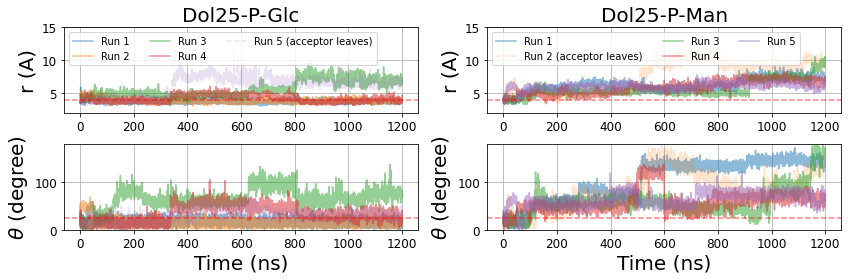

In [160]:
# 1D plots and saving
fig, axs = plt.subplots(2, 2, figsize=(12,4))
r_line = 4.0
theta_line = 25.0
offset = 1
show_idx = [offset, offset+3]
for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
    acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
    ax1 = axs[0,i]
    ax2 = axs[1,i]
    # ax3 = axs[2,i]
    for i_obj ,obj in enumerate(object_list):
        if i_obj == acceptor_leave_idx[i]:
            linestyle = '--'
            alpha=0.2
            label = f'Run {i_obj+1} (acceptor leaves)'
        else:
            linestyle = '-'
            alpha=0.5
            label = f'Run {i_obj+1}'
        x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)
        ax1.plot(x,obj.acceptor_donor_distance, label = label,alpha=alpha, linestyle=linestyle)
        ax2.plot(x,obj.acceptor_donor_angle, label = label,alpha=alpha, linestyle=linestyle)
        # ax3.plot(x,obj.donor_bending_angle, label = label,alpha=alpha, linestyle=linestyle)
    # if i == 0:
    ax1.legend(ncol=3, loc='upper left')
    ax1.set_ylim([2,15])
    ax2.set_ylim([0,180])
    # ax3.set_ylim([110,180])
    # ax1.set_title(object_names[show_idx[i]])
    ax1.set_title(substrate_titles[i], fontsize=20)
    ax1.set_ylabel('r (A)', fontsize=20)
    ax2.set_ylabel(r'$\theta$ (degree)', fontsize=20)
    # ax3.set_ylabel(r'$\theta^{1,4}_{sugar}$', fontsize=20)
    ax2.set_xlabel('Time (ns)', fontsize=20)
    ax1.axhline(r_line, color='r', linestyle='--', alpha=0.5)
    ax2.axhline(theta_line, color='r', linestyle='--', alpha=0.5)
    ax1.grid()
    ax2.grid()
    # ax3.grid()
plt.tight_layout()
filename = figdir+f'1D_r_theta_{suffixes[offset]}_acceptor_stay.png'
plt.savefig(filename, dpi=300)


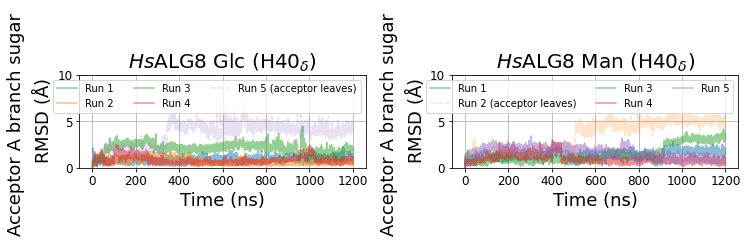

In [161]:
# RMSD
fig, axs = plt.subplots(1,2,figsize=(10.5,2.5))
ylim = [0,10]
for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
    ax = axs[i]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if i_obj == acceptor_leave_idx[i]:
            linestyle = '--'
            alpha=0.2
            label = f'Run {i_obj+1} (acceptor leaves)'
        else:
            linestyle = '-'
            alpha=0.5
            label = f'Run {i_obj+1}'
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.A_sugar_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.A_sugar_rmsd, label = label, linestyle=linestyle, alpha=alpha)

    ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i*3+offset])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Acceptor A branch sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Asugar_'+suffixes[offset]+'_acceptor_stay.png'
plt.savefig(filename)

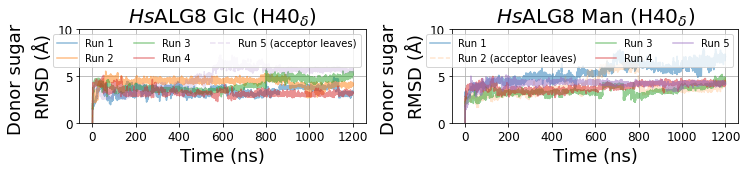

In [162]:
# RMSD
fig, axs = plt.subplots(1,2,figsize=(10.5,2.5))
ylim = [0,10]
for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
    ax = axs[i]
    rmsd = [np.array] * len(object_list)
    for i_obj, obj in enumerate(object_list):
        if i_obj == acceptor_leave_idx[i]:
            linestyle = '--'
            alpha=0.2
            label = f'Run {i_obj+1} (acceptor leaves)'
        else:
            linestyle = '-'
            alpha=0.5
            label = f'Run {i_obj+1}'
        if obj.Donor_substrate:
            rmsd[i_obj] = obj.DS_rmsd
            x = np.arange(0,len(obj.pro_rmsd)/print_out_freq,1/print_out_freq)[:len(obj.pro_rmsd)]
            ax.plot(x,obj.DS_rmsd, label = label, linestyle=linestyle, alpha=alpha)

    ax.legend(ncol=3)
    ax.set_ylim(ylim)
    ax.set_title(object_names[i*3+offset])
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Donor sugar \n' +r'RMSD ($\rm \AA$)')
    ax.grid()
plt.tight_layout()
filename = figdir+'RMSD_Dsugar_'+suffixes[offset]+'_acceptor_stay.png'
plt.savefig(filename)

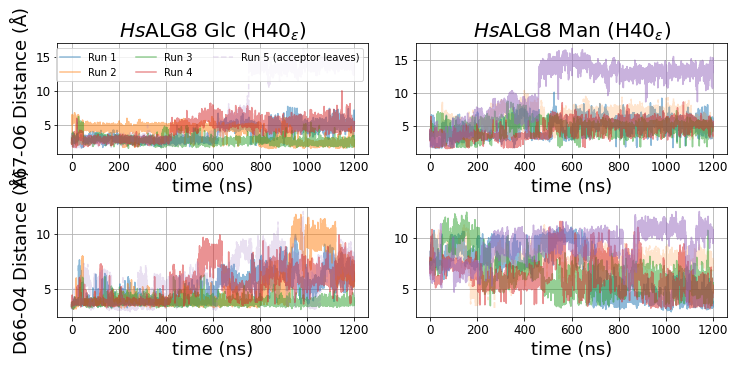

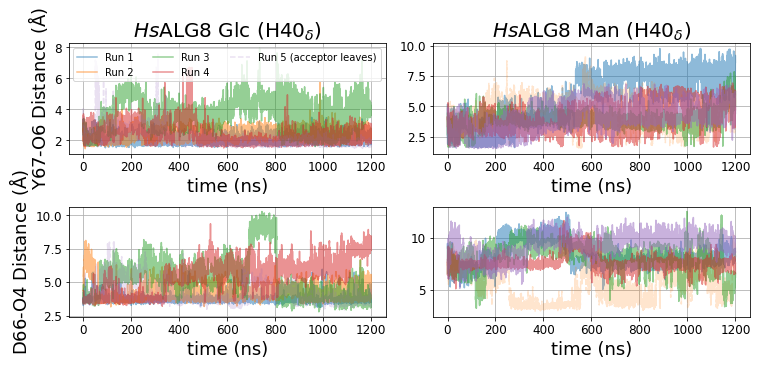

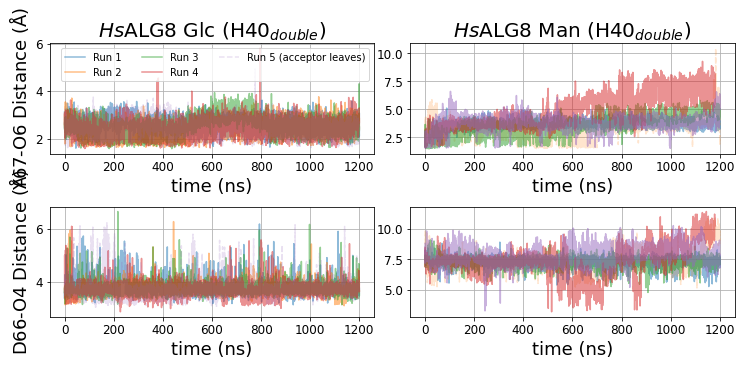

In [163]:
# 1D plots and saving
for offset in range(3):
    fig, axs = plt.subplots(2, 2, figsize=(10.5,5))
    show_idx = [offset, offset+3]
    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        acceptor_donor_distance = np.concatenate([obj.acceptor_donor_distance for obj in object_list])       
        ax1 = axs[0,i]
        ax2 = axs[1,i]
        for i_obj, obj in enumerate(object_list):
            if i_obj == acceptor_leave_idx[i]:
                linestyle = '--'
                alpha=0.2
                label = f'Run {i_obj+1} (acceptor leaves)'
            else:
                linestyle = '-'
                alpha=0.5
                label = f'Run {i_obj+1}'

            x = np.arange(0, len(obj.acceptor_donor_distance)/print_out_freq, 1/print_out_freq)
            ax1.plot(x, obj.Y67_O6_distance, label = label, alpha=alpha, linestyle=linestyle)
            ax2.plot(x, obj.D66_O4_distance, label = label, alpha=alpha, linestyle=linestyle)
        if i == 0:
            ax1.legend(ncol=3, loc='upper right')
        ax1.set_title(object_names[i*3+offset])
        ax1.set_xlabel('time (ns)')
        ax2.set_xlabel('time (ns)')
        if i == 0 or i ==3:
            ax1.set_ylabel(r'Y67-O6 Distance ($\rm \AA$)')
            ax2.set_ylabel(r'D66-O4 Distance ($\rm \AA$)')
        ax1.grid()
        ax2.grid()
    plt.tight_layout()
    filename = figdir+f'1D_distance_Y67_D66_{suffixes[offset]}_acceptor_leaves.png'
    plt.savefig(filename, dpi=300)


# Other Features

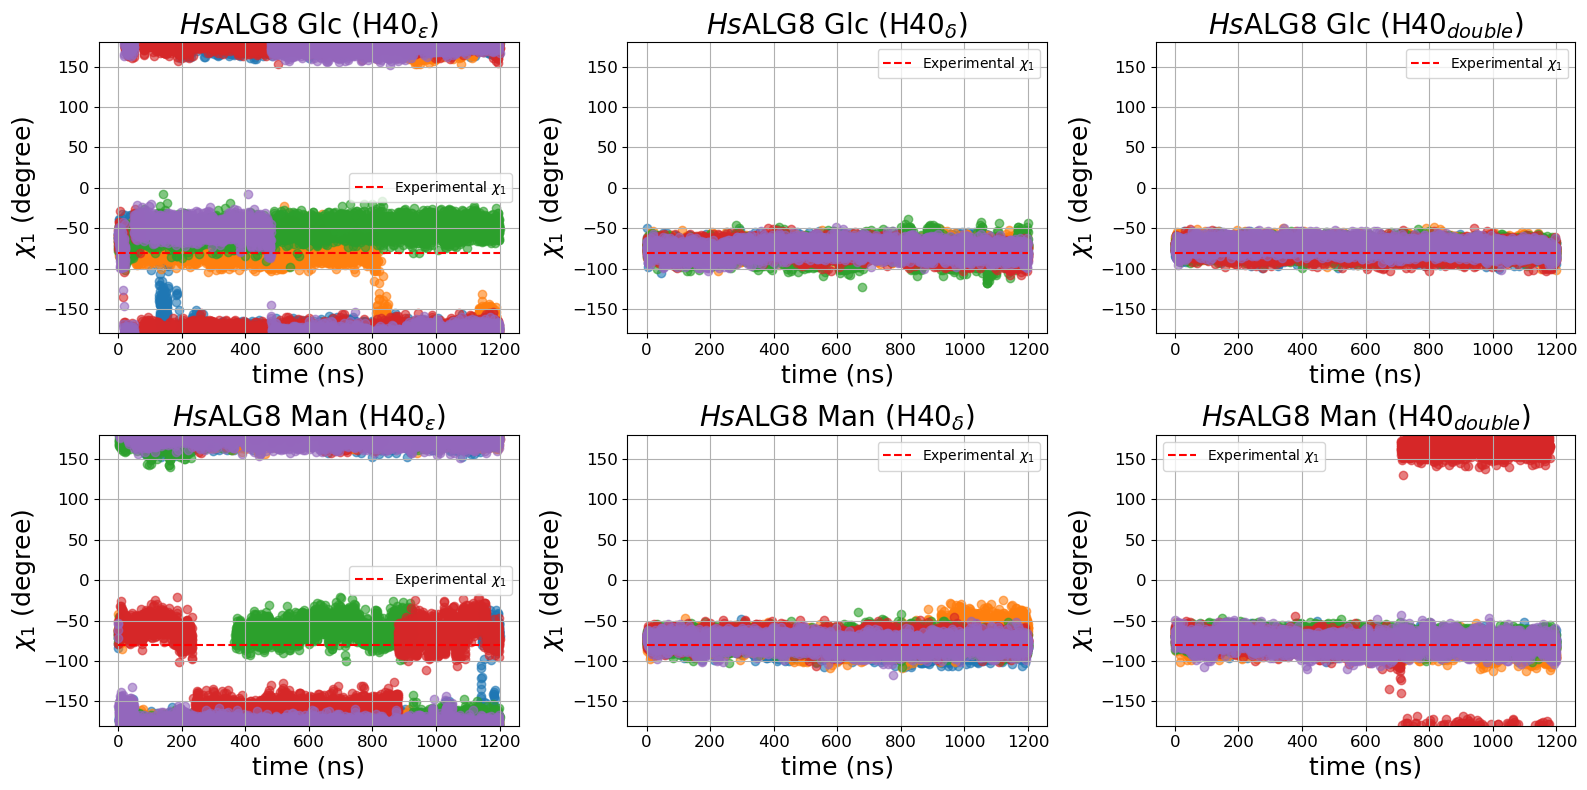

In [164]:
fig, axs = plt.subplots(2,3,figsize=(16,8),dpi=100)
exp_chi1 = -80.29
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    ax = axs[i//3, i%3]
    for i_obj, obj in enumerate(object_list):
        torsion = obj.H40_torsion_chi1
        ax.scatter(np.arange(0,len(torsion)/print_out_freq,1/print_out_freq), torsion, alpha=0.6)
    ax.set_title(object_names[i])
    ax.hlines(exp_chi1, 0, len(torsion)/print_out_freq, colors='r', linestyles='dashed', label='Experimental $\chi_1$')
    ax.set_ylabel(r'$\chi_1$ (degree)')
    ax.set_xlabel(r'time (ns)')
    ax.set_ylim([-180,180])
    ax.grid()
    ax.legend()
plt.tight_layout()
filename = figdir+'H40_torsion_chi1.png'
plt.savefig(filename)


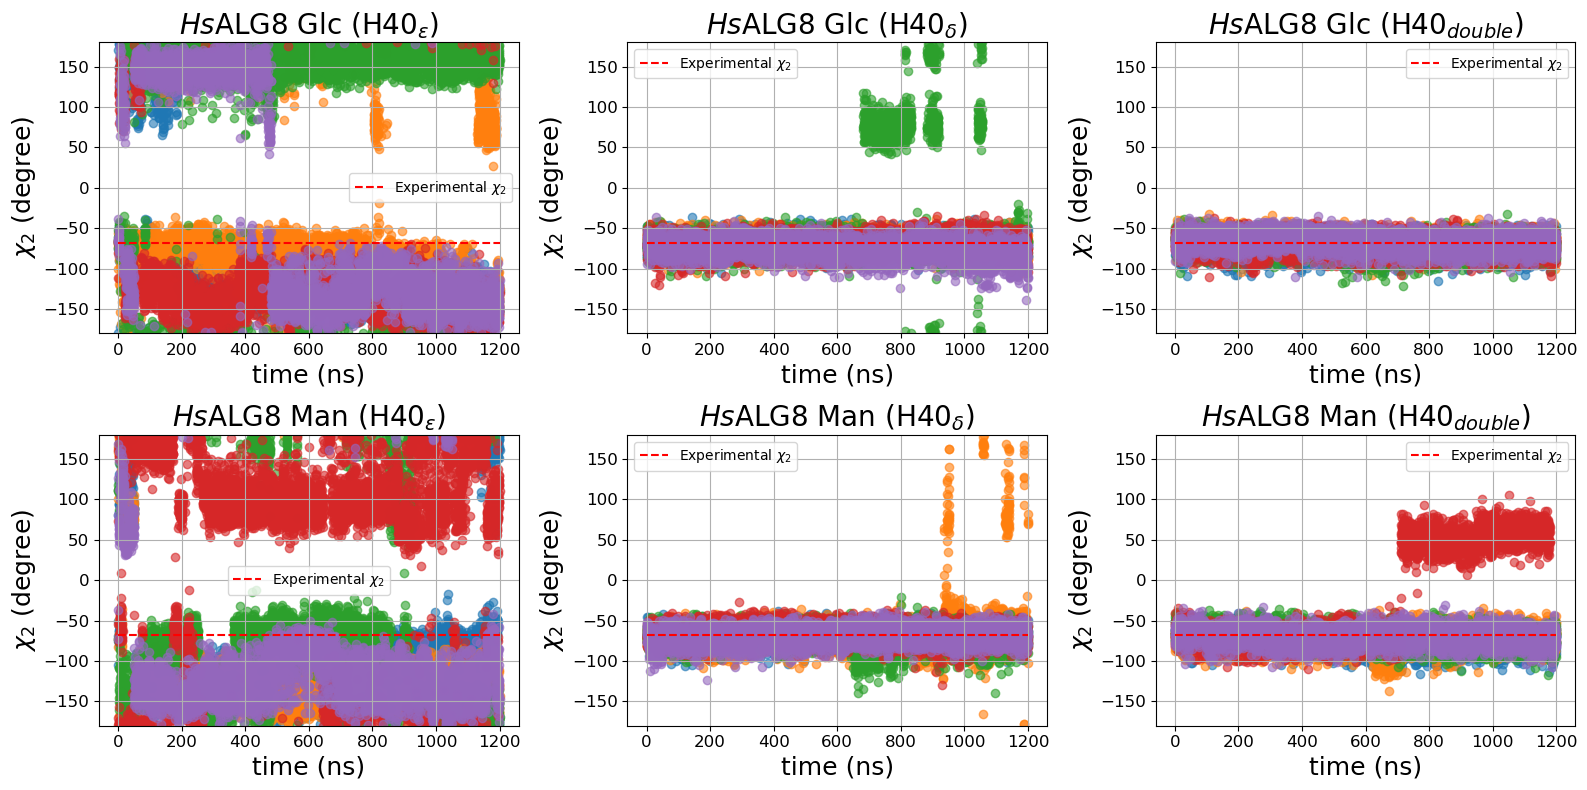

In [165]:
fig, axs = plt.subplots(2,3,figsize=(16,8),dpi=100)
exp_chi2 = -67.94
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    ax = axs[i//3, i%3]
    for i_obj, obj in enumerate(object_list):
        torsion = obj.H40_torsion_chi2
        ax.scatter(np.arange(0,len(torsion)/print_out_freq,1/print_out_freq), torsion, alpha=0.6)
    ax.set_title(object_names[i])
    ax.hlines(exp_chi2, 0, len(torsion)/print_out_freq, colors='r', linestyles='dashed', label='Experimental $\chi_2$')
    ax.set_ylabel(r'$\chi_2$ (degree)')
    ax.set_xlabel(r'time (ns)')
    ax.set_ylim([-180,180])
    ax.grid()
    ax.legend()
plt.tight_layout()
filename = figdir+'H40_torsion_chi2.png'
plt.savefig(filename)


## Y67 - O6

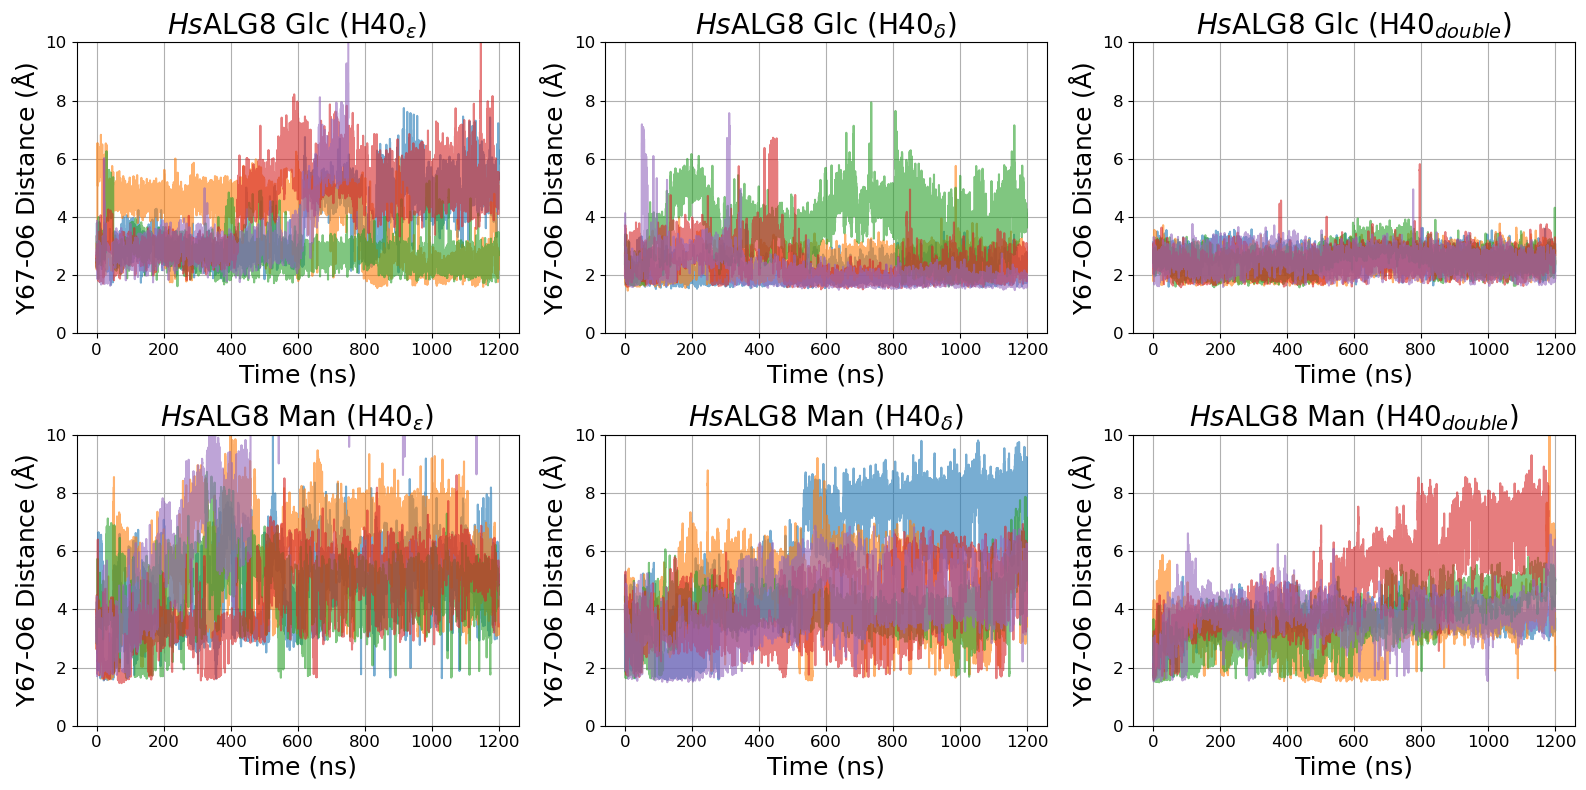

In [166]:
fig, axs = plt.subplots(2,3,figsize=(16,8),dpi=100)
log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    ax = axs[i//3, i%3]
    for i_obj, obj in enumerate(object_list):
        distance = obj.Y67_O6_distance
        ax.plot(np.arange(0,len(distance)/print_out_freq,1/print_out_freq), distance, alpha=0.6)
    ax.set_title(object_names[i])
    ax.set_ylabel(r'Y67-O6 Distance ($\rm \AA$)')
    ax.set_xlabel(r'Time (ns)')
    ax.set_ylim([0,10])
    ax.grid()
plt.tight_layout()
filename = figdir+'Y67_O6_distance.png'
plt.savefig(filename)


## Plot D66-O4 distance

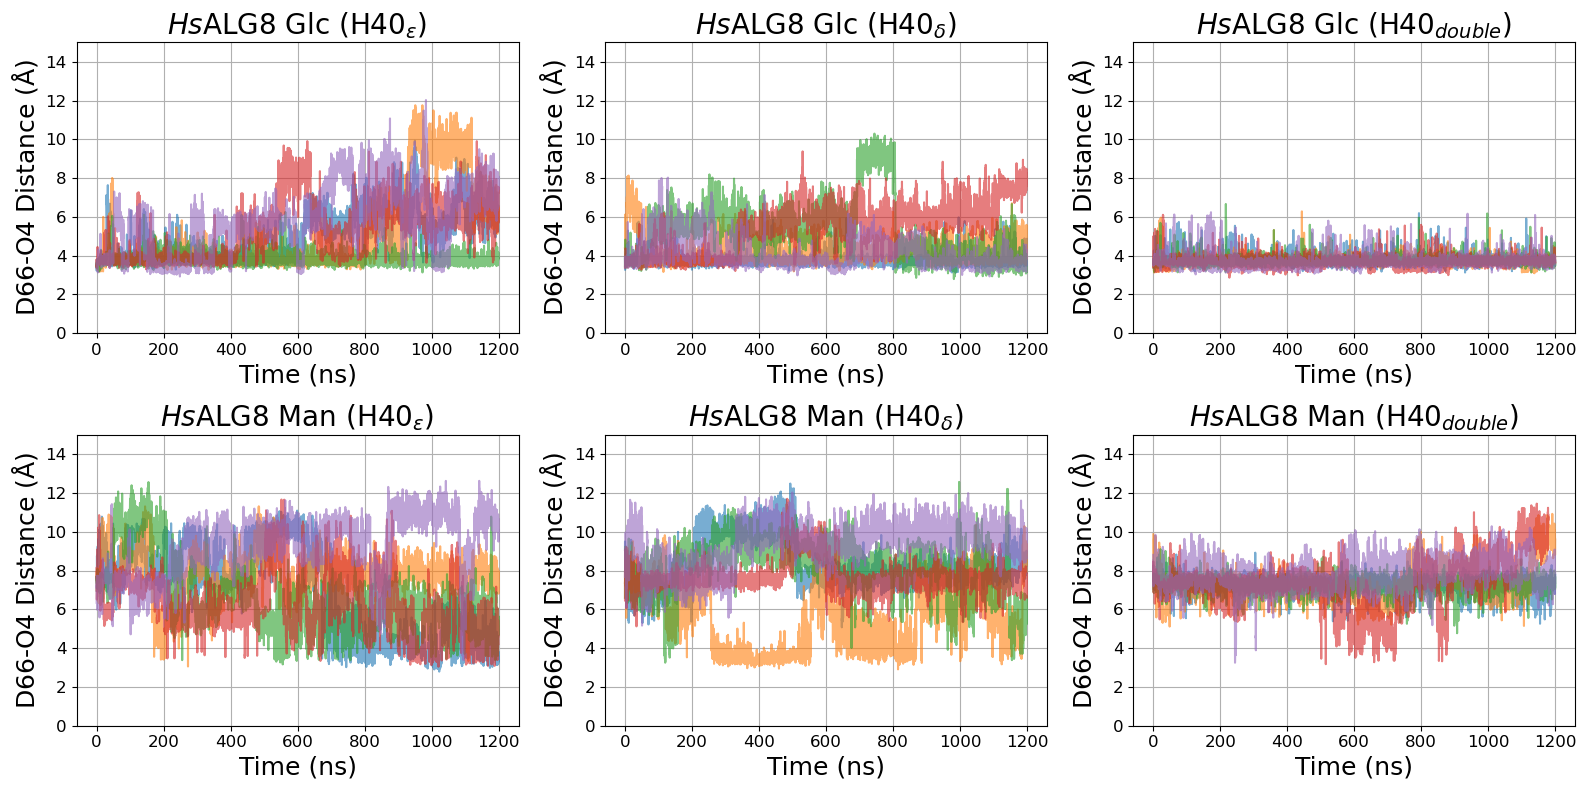

In [167]:
fig, axs = plt.subplots(2,3,figsize=(16,8),dpi=100)

log = False
cmap = 'Blues'
for i, object_list in enumerate(object_lists):
    ax = axs[i//3, i%3]
    for i_obj, obj in enumerate(object_list):
        distance = obj.D66_O4_distance
        ax.plot(np.arange(0,len(distance)/print_out_freq,1/print_out_freq), distance, alpha=0.6)
    ax.set_title(object_names[i])
    ax.set_ylabel(r'D66-O4 Distance ($\rm \AA$)')
    ax.set_xlabel(r'Time (ns)')
    ax.set_ylim([0,15])
    ax.grid()
plt.tight_layout()
filename = figdir+'D66_O4_distance.png'
plt.savefig(filename)


In [168]:
## D36 location and Lipid

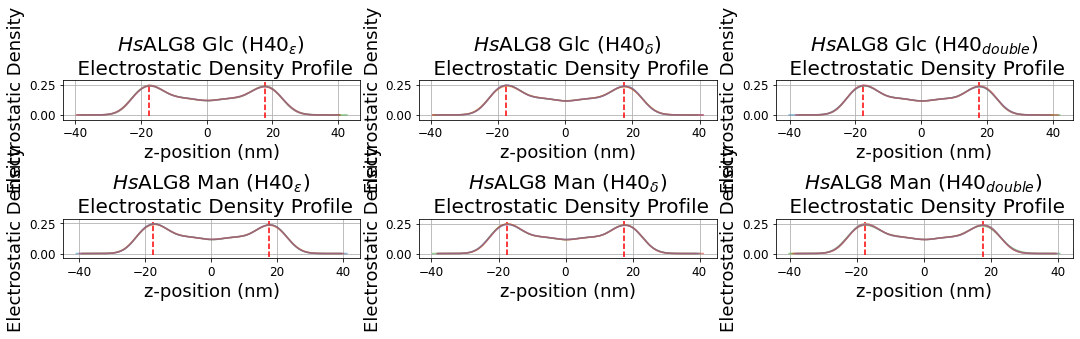

In [169]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
z_lipid = [-17.6, 17.6]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x, E, _ = obj.ele_density.T
        ax.plot(x,E, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(f'{object_names[i_object_list]} \n Electrostatic Density Profile')
    ax.set_xlabel('z-position (nm)')
    ax.set_ylabel(r'Electrostatic Density')
    ax.grid()
for ax in axs:
    for z in z_lipid:
        ax.vlines(z, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red', linestyle='--', alpha=1)
plt.tight_layout()
filename = figdir+'/Electrostatic_density_profile.png'
plt.savefig(filename, dpi=300)

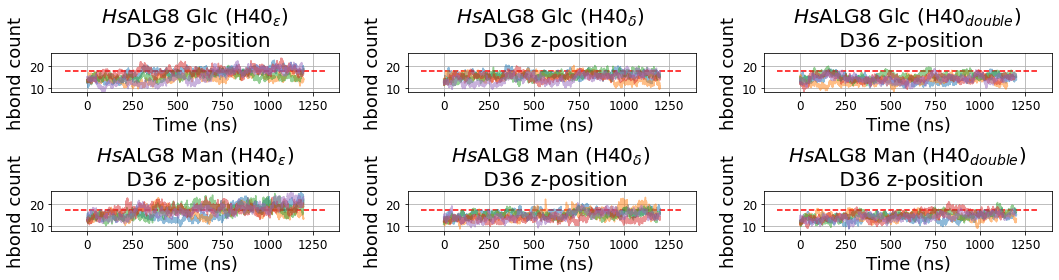

In [170]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        y = obj.D36_z
        x = np.arange(0,len(y)*0.2,0.2)
        if len(x) > len(y):
            x = x[:len(y)]
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.grid()
    ax.set_ylim(ylim)
    ax.set_title(f'{object_names[i_object_list]} \n D36 z-position')
plt.tight_layout()
for ax in axs:
    for z in z_lipid:
        ax.hlines(z, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
filename = figdir+'/D36_z_position_time.png'
plt.savefig(filename, dpi=300)


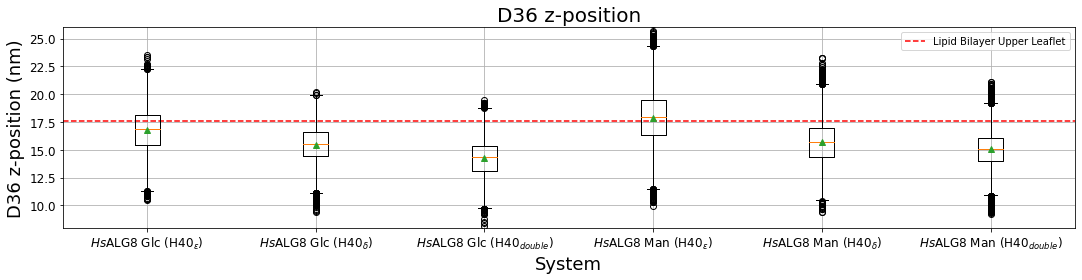

In [171]:
# N36 - F163/H162
fig, ax = plt.subplots(1,1,figsize=(2.5*len(object_lists),4))
discard_frames = 2400
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    z_total = []
    for i_obj, obj in enumerate(object_list):
        z = obj.D36_z
        mask = np.arange(0,len(z)) >= discard_frames
        z_total.append(z[mask])
    ax.boxplot(np.concatenate(z_total), positions=[i_object_list], showmeans=True)
ax.set_xlabel('System')
ax.set_ylabel(r'D36 z-position (nm)')
ax.set_xticks(np.arange(len(object_lists)))
ax.grid()
ax.set_ylim(ylim)
ax.set_title(f'D36 z-position')
ax.set_xticklabels([name for name in object_names], )
plt.tight_layout()
ax.hlines( z_lipid[1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1, label='Lipid Bilayer Upper Leaflet')
ax.legend()
filename = figdir+'/D36_z_position_boxplot.png'
plt.savefig(filename, dpi=300)


# Interaction in bins

In [172]:
# 2D plots and saving
substrate_titles = ['Dol25-P-Glc', 'Dol25-P-Man']
xbins, ybins = np.linspace(-0.5,1.5,3), np.linspace(0,20,30)
for offset in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(3,6), dpi=300)
    show_idx = [offset, offset+3]

    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax = axs[i]
        x = np.concatenate([obj.intra_hydrogen_bonds[1][1][discard:] for obj in object_list])
        y = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
        hist, xedge, yedge, im = ax.hist2d(x,y, bins = (np.linspace(-0.5,1.5,3),np.linspace(0,20,30)),cmap='Blues',density=True)
        im.set_clim(0,0.6)
        fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)        
        ax.set_ylabel(r'r ($\rm \AA$)')
        ax.set_xlabel('C2-OH-OP \n H-bond')
        ax.set_title(substrate_titles[i], fontsize=16)
    plt.tight_layout()
    filename = figdir+f'2D_intra_donor_hbond_r_{suffixes[offset]}_with_titles.png'
    plt.savefig(filename, dpi=300)
    plt.close()



In [173]:
# D66
i_resid = 6
xbins, ybins = np.linspace(-0.5,2.5,4), np.linspace(0,20,30)
for offset in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(2,6), dpi=300)
    show_idx = [offset, offset+3]

    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax = axs[i]
        x = np.concatenate([obj.protein_substrates_bonds[1,i_resid][discard:] for obj in object_list])
        y = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
        hist, xedge, yedge, im = ax.hist2d(x,y, bins = (xbins, ybins),cmap='Blues',density=True)
        im.set_clim(0,0.6)
        # fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)   
        ax.set_ylabel(r'r ($\rm \AA$)')
        ax.set_xlabel(f'{obj.rec_name[i_resid]} \n H-bond')
        ax.set_title(substrate_titles[i], fontsize=16)
    plt.tight_layout()
    filename = figdir+f'2D_D-{obj.rec_name[i_resid]}_r_{suffixes[offset]}_with_titles.png'
    plt.savefig(filename, dpi=300)
    plt.close()



In [174]:
# 2D plots and saving
i_resid = 7
xbins, ybins = np.linspace(-0.5,1.5,3), np.linspace(0,20,30)
for offset in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(2,6), dpi=300)
    show_idx = [offset, offset+3]

    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax = axs[i]
        x = np.concatenate([obj.protein_substrates_bonds[1,i_resid][discard:] for obj in object_list])
        y = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
        hist, xedge, yedge, im = ax.hist2d(x,y, bins = (xbins, ybins),cmap='Blues',density=True)
        im.set_clim(0,0.6)
        # fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)        
        ax.set_ylabel(r'r ($\rm \AA$)')
        # ax.set_xlabel(f'Donor-{obj.rec_name[i_resid]} \n H-bond count')
        ax.set_xlabel(f'{obj.rec_name[i_resid]} \n H-bond')
        ax.set_title(substrate_titles[i], fontsize=16)
    plt.tight_layout()
    filename = figdir+f'2D_D-{obj.rec_name[i_resid]}_r_{suffixes[offset]}_with_titles.png'
    plt.savefig(filename, dpi=300)
    plt.close()



In [175]:
# 2D plots and saving
i_resid = 11
xbins, ybins = np.linspace(-0.5,1.5,3), np.linspace(0,20,30)
for offset in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(2,6), dpi=300)
    show_idx = [offset, offset+3]

    for i, object_list in enumerate([object_lists[offset], object_lists[offset+3]]):
        ax = axs[i]
        x = np.concatenate([obj.protein_substrates_bonds[1,i_resid][discard:] for obj in object_list])
        y = np.concatenate([obj.acceptor_donor_distance[discard:] for obj in object_list])
        hist, xedge, yedge, im = ax.hist2d(x,y, bins = (xbins, ybins),cmap='Blues',density=True)
        im.set_clim(0,0.6)
        # fig.colorbar(im , ax=ax, orientation='vertical',label='Probability Density',shrink=1, aspect=5)        
        ax.set_ylabel(r'r ($\rm \AA$)')
        ax.set_xlabel(f'{obj.rec_name[i_resid]} \n H-bond')
        ax.set_title(substrate_titles[i], fontsize=16)
    plt.tight_layout()
    filename = figdir+f'2D_D-{obj.rec_name[i_resid]}_r_{suffixes[offset]}_with_titles.png'
    plt.savefig(filename, dpi=300)
    plt.close()



# D36 Zaxis

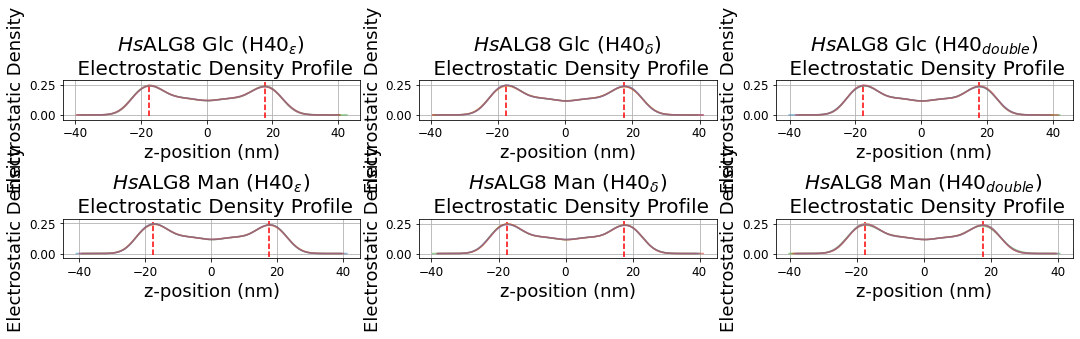

In [176]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
z_lipid = [-17.6, 17.6]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        x, E, _ = obj.ele_density.T
        ax.plot(x,E, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_title(f'{object_names[i_object_list]} \n Electrostatic Density Profile')
    ax.set_xlabel('z-position (nm)')
    ax.set_ylabel(r'Electrostatic Density')
    ax.grid()
for ax in axs:
    for z in z_lipid:
        ax.vlines(z, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], color='red', linestyle='--', alpha=1)
plt.tight_layout()
filename = figdir+'/Electrostatic_density_profile.png'
        

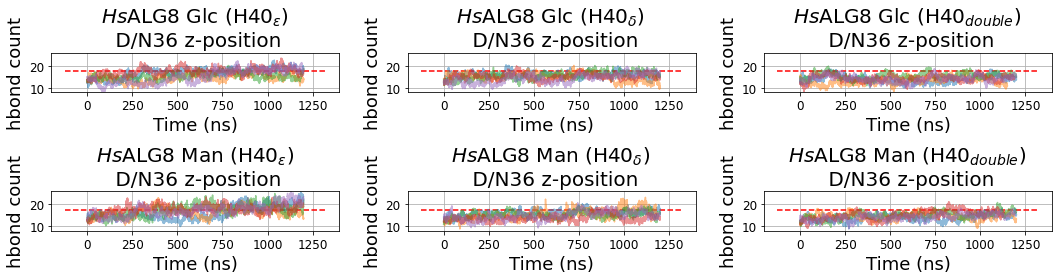

In [177]:
# N36 - F163/H162
fig, axs = plt.subplots(2,3,figsize=(2.5*len(object_lists),4))
axs = axs.flatten()
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    ax = axs[i_object_list]
    for i_obj, obj in enumerate(object_list):
        y = obj.D36_z
        x = np.arange(0,len(y)*0.2,0.2)
        if len(x) > len(y):
            x = x[:len(y)]
        ax.plot(x,y, label = f'Run {i_obj+1}',alpha=0.5)
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel(r'hbond count')
    ax.grid()
    ax.set_ylim(ylim)
    ax.set_title(f'{object_names[i_object_list]} \n D/N36 z-position')
plt.tight_layout()
for ax in axs:
    for z in z_lipid:
        ax.hlines(z, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1)
filename = figdir+'/D36_z_position.png'
plt.savefig(filename, dpi=300)
# filename = figdir+'/N36_F163_interactions.png'
# plt.savefig(filename, dpi=300)


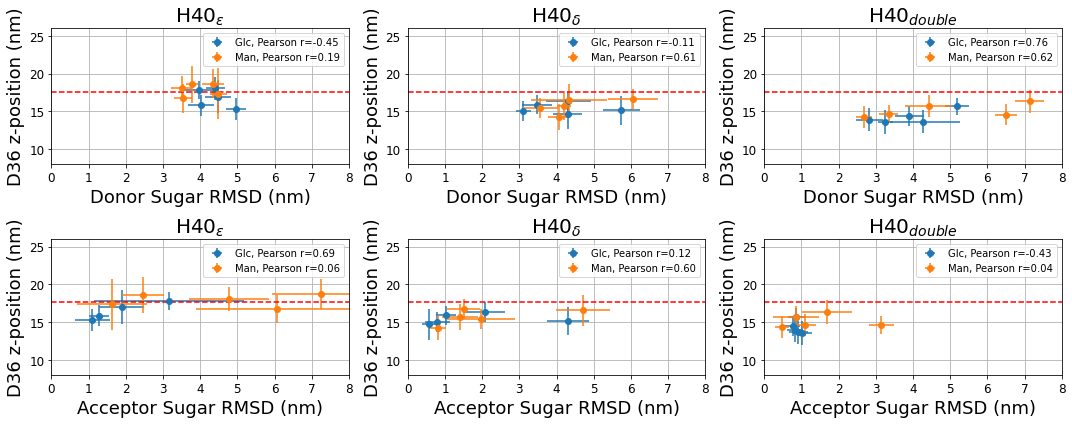

In [178]:
discard_frames = 2400
xlim = [0, 8]
fig, axs = plt.subplots(2,3,figsize=(15,6))
for i_object_list, object_list in enumerate(object_lists):
    
    DS_data = np.zeros([len(object_list), 2]) # avg, std
    AS_data = np.zeros_like(DS_data)
    D36_data = np.zeros_like(DS_data)
    for i_obj, obj in enumerate(object_list):
        # D36_z
        D36_z = obj.D36_z[discard_frames:]
        D36_data[i_obj] = np.mean(D36_z), np.std(D36_z)
        # AS
        AS = obj.A_sugar_rmsd[discard_frames:]
        AS_data[i_obj] = np.mean(AS), np.std(AS)
        # DS
        DS_rmsd = obj.DS_rmsd[discard_frames:]
        DS_data[i_obj] = np.mean(DS_rmsd), np.std(DS_rmsd)
        
    # plot AS vs D36_z
    ax = axs[:,i_object_list%3]
    pearson_r = np.corrcoef(DS_data[:,0], D36_data[:,0])[0,1]
    ax[0].errorbar(DS_data[:,0], D36_data[:,0], xerr=DS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    pearson_r = np.corrcoef(AS_data[:,0], D36_data[:,0])[0,1]
    ax[1].errorbar(AS_data[:,0], D36_data[:,0], xerr=AS_data[:,1], yerr=D36_data[:,1], fmt='o', label=f"{object_names[i_object_list].split(' ')[1]}, Pearson r={pearson_r:.2f}")
    ax[0].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[1].set_title(object_names[i_object_list].split(' ')[2][1:-1])
    ax[0].set_xlabel(r'Donor Sugar RMSD (nm)')
    ax[1].set_xlabel(r'Acceptor Sugar RMSD (nm)')   
    
for ax in axs.flatten():
    ax.hlines(z_lipid[1], xmin=xlim[0], xmax=xlim[1] , color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend()
plt.tight_layout()
filename = figdir+'/D36_z_RMSD_correlation.png'
plt.savefig(filename, dpi=300)
# plt.legend()

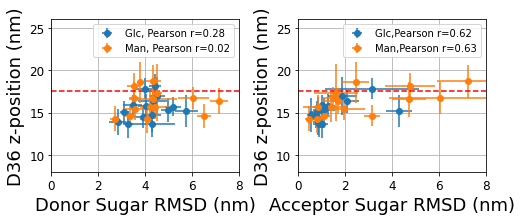

In [179]:
discard_frames = 2400
xlim = [0, 8]
fig, axs = plt.subplots(1,2,figsize=(7,3))
DS_data = np.zeros([6, 5, 2]) # Glc/Man, replicates, avg/std
AS_data = np.zeros_like(DS_data)
D36_data = np.zeros_like(DS_data)
for i_object_list, object_list in enumerate(object_lists):
    for i_obj, obj in enumerate(object_list):
        # D36_z
        D36_z = obj.D36_z[discard_frames:]
        D36_data[i_object_list, i_obj] = np.mean(D36_z), np.std(D36_z)
        # AS
        AS = obj.A_sugar_rmsd[discard_frames:]
        AS_data[i_object_list, i_obj] = np.mean(AS), np.std(AS)
        # DS
        DS_rmsd = obj.DS_rmsd[discard_frames:]
        DS_data[i_object_list, i_obj] = np.mean(DS_rmsd), np.std(DS_rmsd)
        
D36_data = D36_data.reshape(2,15,2)
AS_data = AS_data.reshape(2,15,2)
DS_data = DS_data.reshape(2,15,2)

for sugar_type in range(2):
    sugar_name = 'Glc' if sugar_type ==0 else 'Man'
    pearson_r = np.corrcoef(DS_data[sugar_type,:,0], D36_data[sugar_type,:,0])[0,1]
    axs[0].errorbar(DS_data[sugar_type,:,0], D36_data[sugar_type,:,0], xerr=DS_data[sugar_type,:,1], yerr=D36_data[sugar_type,:,1], fmt='o', label=f"{sugar_name}, Pearson r={pearson_r:.2f}")
    pearson_r = np.corrcoef(AS_data[sugar_type,:,0], D36_data[sugar_type,:,0])[0,1]
    axs[1].errorbar(AS_data[sugar_type,:,0], D36_data[sugar_type,:,0], xerr=AS_data[sugar_type,:,1], yerr=D36_data[sugar_type,:,1], fmt='o', label=f"{sugar_name},Pearson r={pearson_r:.2f}")
    axs[0].set_xlabel(r'Donor Sugar RMSD (nm)')
    axs[1].set_xlabel(r'Acceptor Sugar RMSD (nm)')   

for ax in axs.flatten():
    ax.hlines(z_lipid[1], xmin=xlim[0], xmax=xlim[1] , color='red', linestyle='--', alpha=1)
    ax.grid()
    ax.set_ylabel('D36 z-position (nm)')
    ax.set_ylim(ylim)
    ax.set_xlim(xlim)
    ax.legend()
plt.tight_layout()

# plt.legend()

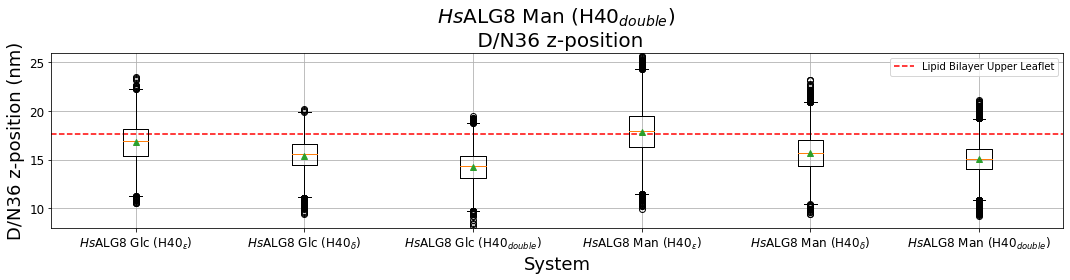

In [180]:
# N36 - F163/H162
fig, ax = plt.subplots(1,1,figsize=(2.5*len(object_lists),4))
discard_frames = 2400
ylim = [8,26]
for i_object_list, object_list in enumerate(object_lists):
    z_total = []
    for i_obj, obj in enumerate(object_list):
        z = obj.D36_z
        mask = np.arange(0,len(z)) >= discard_frames
        z_total.append(z[mask])
    ax.boxplot(np.concatenate(z_total), positions=[i_object_list], showmeans=True)
ax.set_xlabel('System')
ax.set_ylabel(r'D/N36 z-position (nm)')
ax.set_xticks(np.arange(len(object_lists)))
ax.grid()
ax.set_ylim(ylim)
ax.set_title(f'{object_names[i_object_list]} \n D/N36 z-position')
ax.set_xticklabels([name for name in object_names], )
plt.tight_layout()
ax.hlines( z_lipid[1], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], color='red', linestyle='--', alpha=1, label='Lipid Bilayer Upper Leaflet')
ax.legend()
filename = figdir+'/D36_z_position_boxplot.png'
plt.savefig(filename, dpi=300)
